In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os



In [ ]:
#import genotype data
genotype = pd.read_csv(
    "../data/raw/Pf8_drug_resistance_marker_genotypes.tsv",
    sep="\t"
)

In [ ]:
# viewing data
genotype

,Sample,crt_72[C],crt_74[M],crt_75[N],crt_76[K],crt_72-76[CVMNK],crt_93[T],crt_97[H],crt_218[I],crt_220[A],...,mdr1_1034[S],mdr1_1042[N],mdr1_1226[F],mdr1_1246[D],arps10_127-128[VD],fd_193[D],mdr2_484[T],kelch13_349-726_ns_changes,mdr1_dup_call,pm2_dup_call
0,FP0008-C,C,"I,M","E,N","T,K","CVIET,CVMNK",T,H,I,"S,A",...,S,N,F,D,VD,D,T,NaN,0,0
1,FP0009-C,C,I,E,T,CVIET,T,H,I,S,...,S,N,F,Y,VD,D,T,NaN,0,0
2,FP0010-CW,C,"I,M","E,N","T,K","CVIET,CVMNK",T,H,I,"S,A",...,S,N,F,D,VD,D,T,NaN,0,0
3,FP0011-CW,C,"I,M","E,N","T,K","CVIET,CVMNK",T,H,I,"S,A",...,S,N,F,D,VD,D,T,NaN,0,0
4,FP0012-CW,C,I,E,T,CVIET,T,H,I,S,...,S,N,F,D,VD,D,T,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24404,SPT92049,C,M,N,K,CVMNK,T,H,I,A,...,S,N,F,-,VD,D,T,-,-1,-1
24405,SPT92054,C,M,N,K,CVMNK,T,H,I,A,...,S,N,F,D,VD,D,T,NaN,0,-1
24406,SPT92057,C,M,N,K,CVMNK,T,H,I,A,...,S,N,F,D,VD,D,T,-,-1,-1
24407,SPT94772,C,I,E,T,CVIET,T,H,I,S,...,-,-,-,-,VD,D,-,-,-1,-1


### Data exploration

In [ ]:
print(genotype["crt_76[K]"].value_counts(dropna=False))

crt_76[K]
T       12432
K       10768
T,K       607
K,T       550
-          48
T,Q         3
T,Q*        1
Name: count, dtype: int64


In [ ]:
# viewing all column count data
genotype_dic = {}
for col in genotype.columns:
    value_count = genotype[col].value_counts(dropna = False)
    genotype_dic[col] = value_count

In [ ]:
print(genotype_dic)

{'Sample': Sample
FP0008-C     1
FP0009-C     1
FP0010-CW    1
FP0011-CW    1
FP0012-CW    1
            ..
SPT92049     1
SPT92054     1
SPT92057     1
SPT94772     1
SPT94773     1
Name: count, Length: 24409, dtype: int64, 'crt_72[C]': crt_72[C]
C      23955
S        402
-         34
S,C        6
C,S        5
C,Y        5
Y          2
Name: count, dtype: int64, 'crt_74[M]': crt_74[M]
I      11883
M      11318
I,M      612
M,I      544
-         52
Name: count, dtype: int64, 'crt_75[N]': crt_75[N]
N       11205
E       11017
D         839
E,N       594
N,E       525
E,D        71
D,E        62
-          52
N,D        19
D,N         9
E,K         7
N,E*        3
E,N*        3
K           2
K,E         1
Name: count, dtype: int64, 'crt_76[K]': crt_76[K]
T       12432
K       10768
T,K       607
K,T       550
-          48
T,Q         3
T,Q*        1
Name: count, dtype: int64, 'crt_72-76[CVMNK]': crt_72-76[CVMNK]
CVIET           10898
CVMNK           10749
CVIDT             839
CVIET,CV

In [ ]:
genotype.columns

Index(['Sample', 'crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_76[K]',
       'crt_72-76[CVMNK]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]',
       'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]',
       'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_51[N]', 'dhfr_59[C]',
       'dhfr_108[S]', 'dhfr_164[I]', 'dhfr_306[S]', 'dhps_436[S]',
       'dhps_437[G]', 'dhps_540[K]', 'dhps_581[A]', 'dhps_613[A]',
       'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]',
       'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]',
       'fd_193[D]', 'mdr2_484[T]', 'kelch13_349-726_ns_changes',
       'mdr1_dup_call', 'pm2_dup_call'],
      dtype='str')

In [ ]:
# handling kelchi data
genotype['kelch13_349-726_ns_changes'].unique()

<StringArray>
[    nan,     '-', 'a676s', 'p441s', 'E612D', 'A676S', 'S522C', 'a578s',
 's522i', 'e509d',
 ...
 'v566i', 'p527s', 'a427v', 'v566l', 'd641n', 'S364Y', 'V487E', 's477y',
 'T350S', 'c469y']
Length: 266, dtype: str

## Classifying known biomarkers

In [ ]:
genotype.columns

Index(['Sample', 'crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_76[K]',
       'crt_72-76[CVMNK]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]',
       'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]',
       'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_51[N]', 'dhfr_59[C]',
       'dhfr_108[S]', 'dhfr_164[I]', 'dhfr_306[S]', 'dhps_436[S]',
       'dhps_437[G]', 'dhps_540[K]', 'dhps_581[A]', 'dhps_613[A]',
       'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]',
       'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]',
       'fd_193[D]', 'mdr2_484[T]', 'kelch13_349-726_ns_changes',
       'mdr1_dup_call', 'pm2_dup_call'],
      dtype='str')

In [ ]:
# creating a dataframe for known resistance biomakers
encoded = pd.DataFrame()

encoded["Sample"] = genotype["Sample"]

In [ ]:
# markers associated with drug resistance

associated_marker = {

    "dhfr_51[N]": {
        "gene": "dhfr",
        "wildtype": "N",
        "resistant": {"I"}
    },

    "dhfr_59[C]": {
        "gene": "dhfr",
        "wildtype": "C",
        "resistant": {"R"}
    },

    "dhfr_164[I]": {
        "gene": "dhfr",
        "wildtype": "I",
        "resistant": {"L"}
    },


    "dhps_540[K]": {
        "gene": "dhps",
        "wildtype": "K",
        "resistant": {"E"}
    },

    "dhps_581[A]": {
        "gene": "dhps",
        "wildtype": "A",
        "resistant": {"G"}
    },

    "dhps_613[A]": {
        "gene": "dhps",
        "wildtype": "A",
        "resistant": {"S", "T"}
    }
}

In [ ]:
marker_info = {
    "crt_76[K]": {
        "wildtype": "K",
        "resistant": {"T"}
    },

    "dhfr_108[S]": {
        "wildtype": "S",
        "resistant": {"N"}
    },

    "dhps_437[G]": {
        "wildtype": "A",
        "resistant": {"G"}
    }
}

In [ ]:
# known columns
known_marker = {**marker_info,**associated_marker }
known_encoder = []

for col, item in known_marker.items():
    known_encoder.append(col)


In [ ]:
def classify_known_marker(value, wildtype, resistance_alleles):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in {".", "-", "*", "!"}:
        return np.nan

    if "," in value:

        haps = [x.strip().upper() for x in value.split(",")]

        if any(x in {"", "-", "*", "!"} for x in haps):
            return np.nan

        if any(x in resistance_alleles for x in haps):
            return "Resistant"

        if all(x == wildtype.upper() for x in haps):
            return "Sensitive"

        return np.nan

    allele = value.upper()

    if allele in resistance_alleles:
        return "Resistant"

    if allele == wildtype.upper():
        return "Sensitive"

    return np.nan

In [ ]:
# handle mutations causing drug resistance
for column, info in marker_info.items():

    encoded[column] = genotype[column].apply(
        lambda x: classify_known_marker(
            x,
            wildtype=info["wildtype"],
            resistance_alleles=info["resistant"]
        )
    )

In [ ]:
# handle mutations associated with resistance
for column, info in associated_marker.items():
    new_column = f"{column}_assoc"
    encoded[new_column] = genotype[column].apply(
        lambda x: classify_known_marker(
            x,
            wildtype=info["wildtype"],
            resistance_alleles=info["resistant"]
        )
    )

In [ ]:
encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive


#### Handling kelch13

In [ ]:
kelch13_col = "kelch13_349-726_ns_changes"

In [ ]:
k13_resistance = {
    "F446I",
    "N458Y",
    "C469Y",
    "M476I",
    "Y493H",
    "R539T",
    "I543T",
    "P553L",
    "R561H",
    "P574L",
    "C580Y",
    "R622I",
    "A675V"
}

In [ ]:
# classifying k13
def classify_k13(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in {"", ".", "-", "*", "!"}:
        return np.nan

    # Some cells may contain multiple mutations
    mutations = [
        x.strip().upper()
        for x in value.split(",")
    ]

    if any(m in k13_resistance for m in mutations):
        return "Resistant"

    return "Other"

In [ ]:
encoded["kelch13_known"] = genotype[
    "kelch13_349-726_ns_changes"
].apply(classify_k13)

In [ ]:
encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,kelch13_known
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,NaN
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN


#### Handling resistance due to multiple column copy

In [ ]:
# encoding if multiple copies associated with drug resistance
def copy_encoder(value):

    # Missing
    if pd.isna(value) or str(value).strip() == "":
        return np.nan

    value = str(value).strip()

    # ---------- Special: copy number ----------
    # ----- Special: copy number ----------
    
    if int(value) == 0:
        return "Sensitive"
    elif int(value) == 1:
        return "Resistant"
    elif value in {"-", "*", "!"}:
        return np.nan
    else:

        return "rare"


In [ ]:
encoded[["mdr1_dup_call", "pm2_dup_call"]] = genotype[["mdr1_dup_call", "pm2_dup_call"]].map(copy_encoder)


In [ ]:
encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,kelch13_known,mdr1_dup_call,pm2_dup_call
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,NaN,Sensitive,Sensitive
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN,Sensitive,Sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN,Sensitive,Sensitive
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN,Sensitive,Sensitive
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,NaN,Sensitive,Sensitive


In [ ]:
encoded.to_csv('Important_genotype.csv',index = True)

## Handling other columns

In [ ]:
genotype_col = genotype.columns.to_list()
#known_marker.append(["mdr1_dup_call", "pm2_dup_call","kelch13_349-726_ns_changes"])
len(genotype_col)
genotype_col


['Sample',
 'crt_72[C]',
 'crt_74[M]',
 'crt_75[N]',
 'crt_76[K]',
 'crt_72-76[CVMNK]',
 'crt_93[T]',
 'crt_97[H]',
 'crt_218[I]',
 'crt_220[A]',
 'crt_271[Q]',
 'crt_326[N]',
 'crt_333[T]',
 'crt_353[G]',
 'crt_356[I]',
 'crt_371[R]',
 'dhfr_16[N]',
 'dhfr_51[N]',
 'dhfr_59[C]',
 'dhfr_108[S]',
 'dhfr_164[I]',
 'dhfr_306[S]',
 'dhps_436[S]',
 'dhps_437[G]',
 'dhps_540[K]',
 'dhps_581[A]',
 'dhps_613[A]',
 'exo_415[E]',
 'mdr1_86[N]',
 'mdr1_184[Y]',
 'mdr1_1034[S]',
 'mdr1_1042[N]',
 'mdr1_1226[F]',
 'mdr1_1246[D]',
 'arps10_127-128[VD]',
 'fd_193[D]',
 'mdr2_484[T]',
 'kelch13_349-726_ns_changes',
 'mdr1_dup_call',
 'pm2_dup_call']

In [ ]:
rare_col = [
    col for col in genotype.columns
    if col not in known_marker
    and col != "Sample"
]

In [ ]:
exclude = {
    "Sample",
    "crt_72-76[CVMNK]",
    "kelch13_349-726_ns_changes",
    "mdr1_dup_call",
    "pm2_dup_call"
}

rare_col = [
    col for col in genotype.columns
    if col not in known_marker
    and col not in exclude
]

print(rare_col)

['crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]', 'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]', 'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]', 'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]', 'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]', 'fd_193[D]', 'mdr2_484[T]']


### Handling rare mutations

In [ ]:
# extracting rfference ammino acide for rare columns
import re

rare_ref = {}

for col in rare_col:
    match = re.search(r'\[([A-Z]+)\]', col)
    
    if match:
        rare_ref[col] = match.group(1)

print(rare_ref)

{'crt_72[C]': 'C', 'crt_74[M]': 'M', 'crt_75[N]': 'N', 'crt_93[T]': 'T', 'crt_97[H]': 'H', 'crt_218[I]': 'I', 'crt_220[A]': 'A', 'crt_271[Q]': 'Q', 'crt_326[N]': 'N', 'crt_333[T]': 'T', 'crt_353[G]': 'G', 'crt_356[I]': 'I', 'crt_371[R]': 'R', 'dhfr_16[N]': 'N', 'dhfr_306[S]': 'S', 'dhps_436[S]': 'S', 'exo_415[E]': 'E', 'mdr1_86[N]': 'N', 'mdr1_184[Y]': 'Y', 'mdr1_1034[S]': 'S', 'mdr1_1042[N]': 'N', 'mdr1_1226[F]': 'F', 'mdr1_1246[D]': 'D', 'arps10_127-128[VD]': 'VD', 'fd_193[D]': 'D', 'mdr2_484[T]': 'T'}


In [ ]:
# encoding rare (undetermined column)
def encode_rare(value, ref):
    
    # Missing value
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Missing/uncertain symbols
    if value == "" or any(x in value for x in ["*", "!", "."]):
        return np.nan
    
    # Split heterozygous calls
    alleles = [x.strip() for x in value.split(",")]
    
    # If ALL observed alleles are reference
    if all(allele == ref for allele in alleles):
        return "sensitive"
    
    # Any non-reference mutation
    return "Rare"

In [ ]:


for col in rare_col:
    
    ref = rare_ref[col]
    
    encoded[col] = genotype[col].apply(
        lambda x: encode_rare(x, ref)
    )

In [ ]:
encoded

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,...,exo_415[E],mdr1_86[N],mdr1_184[Y],mdr1_1034[S],mdr1_1042[N],mdr1_1226[F],mdr1_1246[D],arps10_127-128[VD],fd_193[D],mdr2_484[T]
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,Rare,Rare,sensitive,sensitive,sensitive,Rare,sensitive,sensitive,sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,Rare,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,Rare,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24404,SPT92049,Sensitive,Resistant,NaN,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,Rare,sensitive,sensitive,sensitive
24405,SPT92054,Sensitive,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
24406,SPT92057,Sensitive,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive
24407,SPT94772,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,Rare,Rare,Rare,Rare,Rare,sensitive,sensitive,Rare


In [ ]:
encoded.shape

(24409, 39)

# Handling the drug phenotype

In [ ]:
# loading sample metadata
metadata = pd.read_csv("../data/raw/Pf8-samples.csv")

In [ ]:
metadata.columns

Index(['sample_id', 'year', 'qc_pass', 'study_id', 'region', 'country',
       'country_id', 'site', 'site_id', 'ARTresistant', 'CQresistant',
       'MQresistant', 'PPQresistant', 'PYRresistant', 'SDXresistant'],
      dtype='str')

In [ ]:
# dropping unnecessary columns
del_col = ['year', 'qc_pass', 'study_id', 'region', 'country', 'country_id', 'site', 'site_id']

In [ ]:
merged_encoded = encoded.merge(metadata, left_on = 'Sample', right_on = 'sample_id', how = 'left')

In [ ]:
merged_encoded.columns

Index(['Sample', 'crt_76[K]', 'dhfr_108[S]', 'dhps_437[G]', 'dhfr_51[N]_assoc',
       'dhfr_59[C]_assoc', 'dhfr_164[I]_assoc', 'dhps_540[K]_assoc',
       'dhps_581[A]_assoc', 'dhps_613[A]_assoc', 'kelch13_known',
       'mdr1_dup_call', 'pm2_dup_call', 'crt_72[C]', 'crt_74[M]', 'crt_75[N]',
       'crt_93[T]', 'crt_97[H]', 'crt_218[I]', 'crt_220[A]', 'crt_271[Q]',
       'crt_326[N]', 'crt_333[T]', 'crt_353[G]', 'crt_356[I]', 'crt_371[R]',
       'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]', 'exo_415[E]', 'mdr1_86[N]',
       'mdr1_184[Y]', 'mdr1_1034[S]', 'mdr1_1042[N]', 'mdr1_1226[F]',
       'mdr1_1246[D]', 'arps10_127-128[VD]', 'fd_193[D]', 'mdr2_484[T]',
       'sample_id', 'ARTresistant', 'CQresistant', 'MQresistant',
       'PPQresistant', 'PYRresistant', 'SDXresistant'],
      dtype='str')

In [ ]:
merged_encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,...,country,country_id,site,site_id,ARTresistant,CQresistant,MQresistant,PPQresistant,PYRresistant,SDXresistant
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,sensitive,sensitive,undetermined,undetermined
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,sensitive,sensitive,resistant,sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,resistant
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,undetermined
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,undetermined,undetermined,resistant,sensitive


In [ ]:
merged_encoded.shape

(24409, 54)

In [ ]:
# removing unnecessary columns 
merged_encoded.drop(columns = del_col, inplace = True)

In [ ]:
merged_encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,...,arps10_127-128[VD],fd_193[D],mdr2_484[T],sample_id,ARTresistant,CQresistant,MQresistant,PPQresistant,PYRresistant,SDXresistant
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,FP0008-C,sensitive,undetermined,sensitive,sensitive,undetermined,undetermined
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,FP0009-C,sensitive,resistant,sensitive,sensitive,resistant,sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,FP0010-CW,sensitive,undetermined,undetermined,undetermined,resistant,resistant
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,FP0011-CW,sensitive,undetermined,undetermined,undetermined,resistant,undetermined
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,FP0012-CW,sensitive,resistant,undetermined,undetermined,resistant,sensitive


In [ ]:
merged_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 24409 entries, 0 to 24408
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Sample              24409 non-null  str  
 1   crt_76[K]           24361 non-null  str  
 2   dhfr_108[S]         23995 non-null  str  
 3   dhps_437[G]         24139 non-null  str  
 4   dhfr_51[N]_assoc    24112 non-null  str  
 5   dhfr_59[C]_assoc    24085 non-null  str  
 6   dhfr_164[I]_assoc   24138 non-null  str  
 7   dhps_540[K]_assoc   21236 non-null  str  
 8   dhps_581[A]_assoc   24044 non-null  str  
 9   dhps_613[A]_assoc   24103 non-null  str  
 10  kelch13_known       4464 non-null   str  
 11  mdr1_dup_call       24409 non-null  str  
 12  pm2_dup_call        24409 non-null  str  
 13  crt_72[C]           24409 non-null  str  
 14  crt_74[M]           24409 non-null  str  
 15  crt_75[N]           24403 non-null  str  
 16  crt_93[T]           24409 non-null  str  
 17  crt_

In [ ]:
merged_encoded['dhfr_51[N]_assoc'].value_counts(dropna=False)

dhfr_51[N]_assoc
Resistant    20083
Sensitive     4029
NaN            297
Name: count, dtype: int64

## Handling target columns

In [ ]:
target_df = merged_encoded[['ARTresistant', 'CQresistant',
       'MQresistant', 'PPQresistant', 'PYRresistant', 'SDXresistant']]

In [ ]:
target_col = ['ARTresistant', 'CQresistant','MQresistant', 'PPQresistant', 'PYRresistant', 'SDXresistant']

In [ ]:
pd.set_option('display.max_rows', None)
for col in target_df.columns:
    print(f"\n{col}")
    print(target_df[col].value_counts(dropna=False))


ARTresistant
ARTresistant
sensitive       17147
resistant        3905
undetermined     3357
Name: count, dtype: int64

CQresistant
CQresistant
resistant       12432
sensitive       10768
undetermined     1209
Name: count, dtype: int64

MQresistant
MQresistant
sensitive       12598
undetermined    11153
resistant         658
Name: count, dtype: int64

PPQresistant
PPQresistant
sensitive       13467
undetermined    10454
resistant         488
Name: count, dtype: int64

PYRresistant
PYRresistant
resistant       21964
undetermined     1230
sensitive        1215
Name: count, dtype: int64

SDXresistant
SDXresistant
resistant       19270
sensitive        3601
undetermined     1538
Name: count, dtype: int64


#### visualizing drug propotion

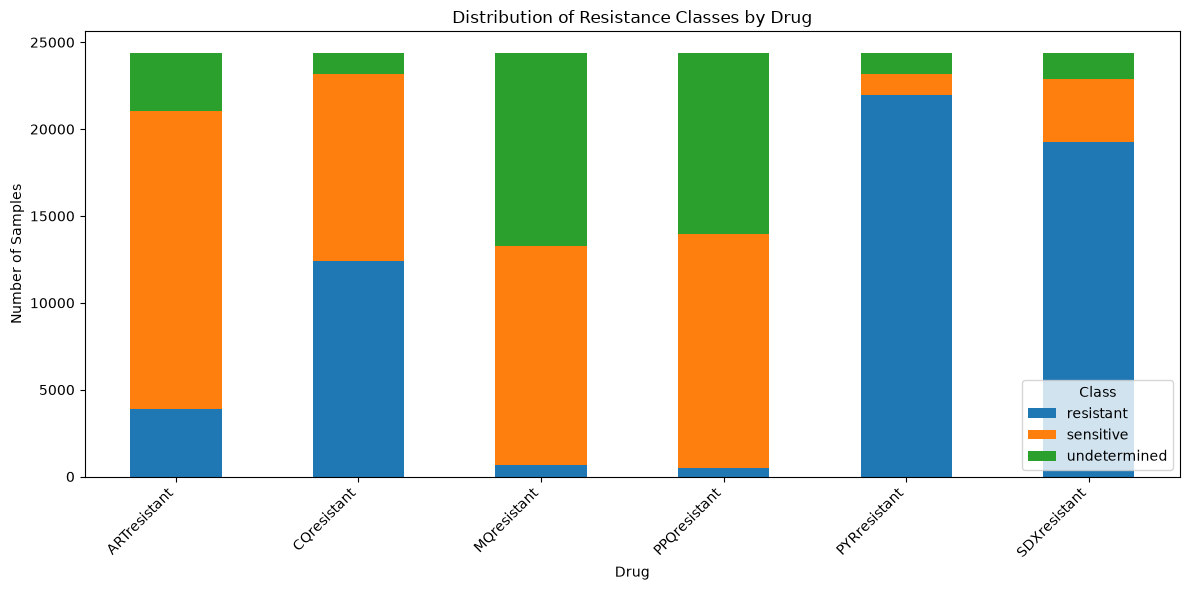

In [ ]:
import matplotlib.pyplot as plt
import os

# Create folder
os.makedirs("../processed/target_distribution_plots", exist_ok=True)

# Count each class for each target
counts = target_df.apply(
    lambda col: col.value_counts(dropna=False)
).T

# Plot
counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribution of Resistance Classes by Drug")
plt.xlabel("Drug")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Class")
plt.tight_layout()

# Save as PNG
plt.savefig(
    "../processed/target_distribution_plots/resistance_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

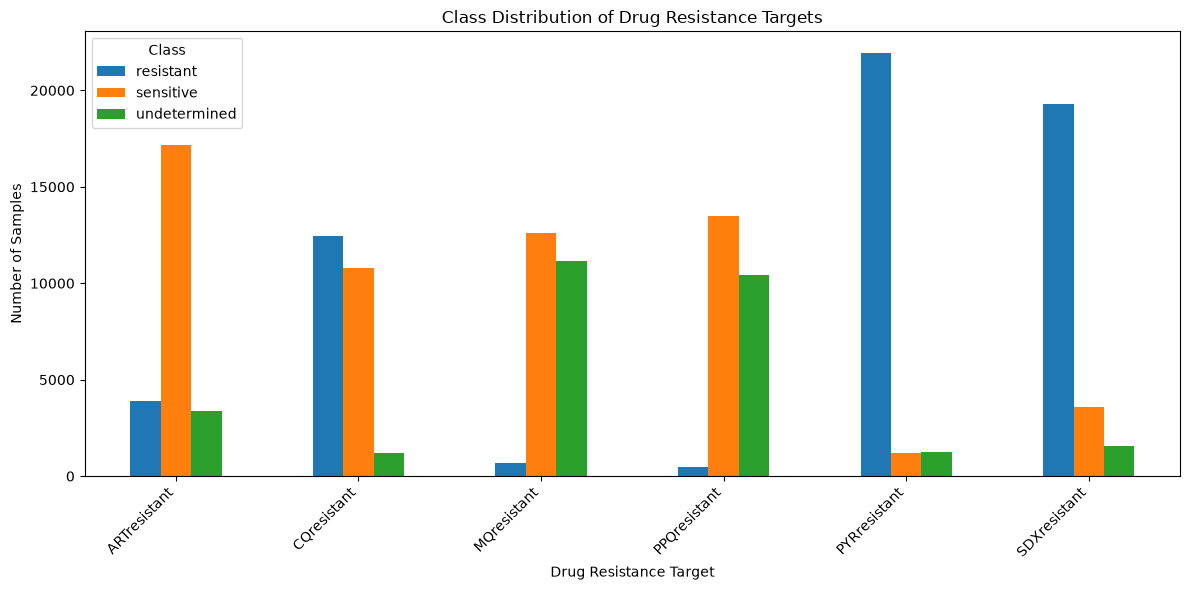

In [ ]:
import matplotlib.pyplot as plt

counts = target_df.apply(
    lambda col: col.value_counts(dropna=False)
).T

ax = counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Class Distribution of Drug Resistance Targets")
plt.xlabel("Drug Resistance Target")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### Encoding the y_target column

In [ ]:
import numpy as np

Y = merged_encoded[target_col].replace({
    "sensitive": 0,
    "resistant": 1,
    "undetermined": 0
})

In [ ]:
Y.head()

,ARTresistant,CQresistant,MQresistant,PPQresistant,PYRresistant,SDXresistant
0,0,0,0,0,0,0
1,0,1,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,0,1,0
4,0,1,0,0,1,0


## Encoding features variable

In [ ]:
features_df = merged_encoded.drop(columns = target_col)

In [ ]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24409 entries, 0 to 24408
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Sample              24409 non-null  str  
 1   crt_76[K]           24361 non-null  str  
 2   dhfr_108[S]         23995 non-null  str  
 3   dhps_437[G]         24139 non-null  str  
 4   dhfr_51[N]_assoc    24112 non-null  str  
 5   dhfr_59[C]_assoc    24085 non-null  str  
 6   dhfr_164[I]_assoc   24138 non-null  str  
 7   dhps_540[K]_assoc   21236 non-null  str  
 8   dhps_581[A]_assoc   24044 non-null  str  
 9   dhps_613[A]_assoc   24103 non-null  str  
 10  kelch13_known       4464 non-null   str  
 11  mdr1_dup_call       24409 non-null  str  
 12  pm2_dup_call        24409 non-null  str  
 13  crt_72[C]           24409 non-null  str  
 14  crt_74[M]           24409 non-null  str  
 15  crt_75[N]           24403 non-null  str  
 16  crt_93[T]           24409 non-null  str  
 17  crt_

In [ ]:
features_df.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,...,mdr1_86[N],mdr1_184[Y],mdr1_1034[S],mdr1_1042[N],mdr1_1226[F],mdr1_1246[D],arps10_127-128[VD],fd_193[D],mdr2_484[T],sample_id
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,FP0008-C
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,Rare,sensitive,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,FP0009-C
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,FP0010-CW
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,FP0011-CW
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,FP0012-CW


In [ ]:
features_df = features_df.drop(
    columns=["Sample", "sample_id"],
    errors="ignore"
).copy()

In [ ]:
for col in features_df.columns:
    print(f"\n===== {col} =====")
    print(features_df[col].value_counts(dropna=False))


===== crt_76[K] =====
crt_76[K]
Resistant    13593
Sensitive    10768
NaN             48
Name: count, dtype: int64

===== dhfr_108[S] =====
dhfr_108[S]
Resistant    22780
Sensitive     1215
NaN            414
Name: count, dtype: int64

===== dhps_437[G] =====
dhps_437[G]
Resistant    20538
Sensitive     3601
NaN            270
Name: count, dtype: int64

===== dhfr_51[N]_assoc =====
dhfr_51[N]_assoc
Resistant    20083
Sensitive     4029
NaN            297
Name: count, dtype: int64

===== dhfr_59[C]_assoc =====
dhfr_59[C]_assoc
Resistant    22051
Sensitive     2034
NaN            324
Name: count, dtype: int64

===== dhfr_164[I]_assoc =====
dhfr_164[I]_assoc
Sensitive    19106
Resistant     5032
NaN            271
Name: count, dtype: int64

===== dhps_540[K]_assoc =====
dhps_540[K]_assoc
Sensitive    12850
Resistant     8386
NaN           3173
Name: count, dtype: int64

===== dhps_581[A]_assoc =====
dhps_581[A]_assoc
Sensitive    18695
Resistant     5349
NaN            365
Name: count, d

In [ ]:
features_df = features_df[
    features_df['dhps_613[A]_assoc'] != "Other"
].copy()

In [ ]:
for col in features_df.columns:
    print(f"\n===== {col} =====")
    print(features_df[col].value_counts(dropna=False))


===== crt_76[K] =====
crt_76[K]
Resistant    13593
Sensitive    10768
NaN             48
Name: count, dtype: int64

===== dhfr_108[S] =====
dhfr_108[S]
Resistant    22780
Sensitive     1215
NaN            414
Name: count, dtype: int64

===== dhps_437[G] =====
dhps_437[G]
Resistant    20538
Sensitive     3601
NaN            270
Name: count, dtype: int64

===== dhfr_51[N]_assoc =====
dhfr_51[N]_assoc
Resistant    20083
Sensitive     4029
NaN            297
Name: count, dtype: int64

===== dhfr_59[C]_assoc =====
dhfr_59[C]_assoc
Resistant    22051
Sensitive     2034
NaN            324
Name: count, dtype: int64

===== dhfr_164[I]_assoc =====
dhfr_164[I]_assoc
Sensitive    19106
Resistant     5032
NaN            271
Name: count, dtype: int64

===== dhps_540[K]_assoc =====
dhps_540[K]_assoc
Sensitive    12850
Resistant     8386
NaN           3173
Name: count, dtype: int64

===== dhps_581[A]_assoc =====
dhps_581[A]_assoc
Sensitive    18695
Resistant     5349
NaN            365
Name: count, d

In [ ]:
features_df['crt_371[R]'].value_counts()

crt_371[R]
Rare         12455
sensitive    11954
Name: count, dtype: int64

### Encoding the X features

In [ ]:
# defining different columns 
known_cols = list(marker_info.keys())
known_cols.append("mdr1_dup_call")
known_cols.append("pm2_dup_call")


associated_cols = list(associated_marker.keys())

rare_cols = rare_col

In [ ]:
print("Known:", known_cols)
print("Associated:", associated_cols)
print("Rare:", rare_cols)

Known: ['crt_76[K]', 'dhfr_108[S]', 'dhps_437[G]', 'mdr1_dup_call', 'pm2_dup_call']
Associated: ['dhfr_51[N]', 'dhfr_59[C]', 'dhfr_164[I]', 'dhps_540[K]', 'dhps_581[A]', 'dhps_613[A]']
Rare: ['crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]', 'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]', 'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]', 'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]', 'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]', 'fd_193[D]', 'mdr2_484[T]']


In [ ]:
associated_cols.append("mdr1_dup_call")
associated_cols.append("pm2_dup_call")

In [ ]:
print("Rare:", rare_cols)

Rare: ['crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]', 'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]', 'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]', 'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]', 'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]', 'fd_193[D]', 'mdr2_484[T]']


In [ ]:
print([c for c in features_df.columns if 'dhfr' in c or 'dhps' in c])

['dhfr_108[S]', 'dhps_437[G]', 'dhfr_51[N]_assoc', 'dhfr_59[C]_assoc', 'dhfr_164[I]_assoc', 'dhps_540[K]_assoc', 'dhps_581[A]_assoc', 'dhps_613[A]_assoc', 'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]']


In [ ]:
assoc_col = [c for c in encoded.columns if '_assoc' in c]

In [ ]:
# encoding known and associated columns

X_known = features_df[known_cols].replace({
    "Resistant": 1,
    "Sensitive": 0,
    "sensitive": 0,
    "rare": 0.2
})

X_associated = features_df[assoc_col].replace({
    "Resistant": 1,
    "Sensitive": 0,
    "sensitive": 0,
    "rare": 0.2
})

In [ ]:
# viewing columns associated with known resistance
for col in known_cols:
    print(col, X_known[col].value_counts(dropna=False))

crt_76[K] crt_76[K]
0.5    13593
0      10768
NaN       48
Name: count, dtype: int64
dhfr_108[S] dhfr_108[S]
0.5    22780
0       1215
NaN      414
Name: count, dtype: int64
dhps_437[G] dhps_437[G]
0.5    20538
0       3601
NaN      270
Name: count, dtype: int64
mdr1_dup_call mdr1_dup_call
0      19512
0.2     4195
0.5      702
Name: count, dtype: int64
pm2_dup_call pm2_dup_call
0      17610
0.2     4719
0.5     2080
Name: count, dtype: int64


In [ ]:
# viewing columns assocciated with resistance associations
for col in assoc_col:
    print(col, X_associated[col].value_counts(dropna=False))

dhfr_51[N]_assoc dhfr_51[N]_assoc
1      20083
0       4029
NaN      297
Name: count, dtype: int64
dhfr_59[C]_assoc dhfr_59[C]_assoc
1      22051
0       2034
NaN      324
Name: count, dtype: int64
dhfr_164[I]_assoc dhfr_164[I]_assoc
0      19106
1       5032
NaN      271
Name: count, dtype: int64
dhps_540[K]_assoc dhps_540[K]_assoc
0      12850
1       8386
NaN     3173
Name: count, dtype: int64
dhps_581[A]_assoc dhps_581[A]_assoc
0      18695
1       5349
NaN      365
Name: count, dtype: int64
dhps_613[A]_assoc dhps_613[A]_assoc
0      22744
1       1359
NaN      306
Name: count, dtype: int64


In [ ]:
print(type(rare_cols))
print(rare_cols)

<class 'list'>
['crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]', 'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]', 'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_306[S]', 'dhps_436[S]', 'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]', 'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]', 'fd_193[D]', 'mdr2_484[T]']


In [ ]:
# Handling rare mutations
X_rare = features_df[rare_cols].replace({
    "sensitive": 0,
    "Sensitive": 0,
    "Rare": 0.2,
    
})

In [ ]:
# merging all three
X = pd.concat([ X_rare, X_associated,X_known],axis=1)

print("X shape:", X.shape)
X.head()

X shape: (24409, 37)


,crt_72[C],crt_74[M],crt_75[N],crt_93[T],crt_97[H],crt_218[I],crt_220[A],crt_271[Q],crt_326[N],crt_333[T],...,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,crt_76[K],dhfr_108[S],dhps_437[G],mdr1_dup_call,pm2_dup_call
0,0,0.2,0.2,0,0,0,0.2,0.2,0,0,...,0,0,0,0,0,0.5,0.5,0.5,0,0
1,0,0.2,0.2,0,0,0,0.2,0.2,0,0,...,1,0,0,0,0,0.5,0.5,0,0,0
2,0,0.2,0.2,0,0,0,0.2,0.2,0,0,...,1,0,0,0,0,0.5,0.5,0.5,0,0
3,0,0.2,0.2,0,0,0,0.2,0.2,0.2,0,...,1,0,0,0,0,0.5,0.5,0.5,0,0
4,0,0.2,0.2,0,0,0,0.2,0.2,0,0,...,1,0,0,0,0,0.5,0.5,0,0,0


In [ ]:
# merging  when  dealing with X_rare and X_known only
#X = pd.concat([ X_rare, X_associated],axis=1)

#print("X shape:", X.shape)
#X.head()

In [ ]:
# when dealing with rare column only
#X = X_rare.copy()

In [ ]:
X.shape

(24409, 37)

In [ ]:
Y.shape

(24409, 6)

In [ ]:
y = Y.apply(pd.to_numeric, errors="coerce")

In [ ]:
X = X.apply(pd.to_numeric, errors="coerce")

## Model

In [ ]:
mask = Y.notna().all(axis=1)

X_model = X.loc[mask]
y_model = Y.loc[mask]

print(X_model.shape)
print(y_model.shape)

(24409, 37)
(24409, 6)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

In [ ]:
mask = y.notna().all(axis=1)

X_model = X.loc[mask].copy()
y_model = y.loc[mask].copy()

In [ ]:
print("X:", X_model.shape)
print("y:", y_model.shape)

print(y_model.dtypes)
print(y_model.apply(lambda x: x.unique()))

X: (24409, 37)
y: (24409, 6)
ARTresistant    int64
CQresistant     int64
MQresistant     int64
PPQresistant    int64
PYRresistant    int64
SDXresistant    int64
dtype: object
   ARTresistant  CQresistant  MQresistant  PPQresistant  PYRresistant  \
0             0            0            0             0             0   
1             1            1            1             1             1   

   SDXresistant  
0             0  
1             1  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.multiclass import type_of_target

# Create a fresh train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

# Check the target
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("y_train dtype:")
print(y_train.dtypes)

print("\nTarget type:")
print(type_of_target(y_train))

X_train: (19527, 37)
y_train: (19527, 6)
y_train dtype:
ARTresistant    int64
CQresistant     int64
MQresistant     int64
PPQresistant    int64
PYRresistant    int64
SDXresistant    int64
dtype: object

Target type:
multilabel-indicator


In [ ]:
from sklearn.utils.multiclass import type_of_target

print(type_of_target(y_model))

multilabel-indicator


## RandomForest classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(y_pred.shape)
from sklearn.metrics import classification_report

for i, drug in enumerate(y.columns):
    print(f"\n===== {drug} ===rf==")
    print(
        classification_report(
            y_test.iloc[:, i],
            y_pred[:, i]
        )
    )
#self
y_self_pred = rf.predict(X_train)
for i, drug in enumerate(y.columns):
    print(f"\n===== {drug} ==rf===")
    print(
        classification_report(
            y_train.iloc[:, i],
            y_self_pred[:, i]
        )
    )


(4882, 6)

===== ARTresistant ===rf==
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4071
           1       0.89      0.89      0.89       811

    accuracy                           0.96      4882
   macro avg       0.93      0.93      0.93      4882
weighted avg       0.96      0.96      0.96      4882


===== CQresistant ===rf==
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2399
           1       0.94      0.99      0.96      2483

    accuracy                           0.96      4882
   macro avg       0.96      0.96      0.96      4882
weighted avg       0.96      0.96      0.96      4882


===== MQresistant ===rf==
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4756
           1       0.98      0.98      0.98       126

    accuracy                           1.00      4882
   macro avg       0.99      0.99   

## using weights with Randomforest

In [ ]:
rf_models = {}
y_pred_rf = {}

for drug in y_train.columns:

    n0 = (y_train[drug] == 0).sum()
    n1 = (y_train[drug] == 1).sum()

    weight = n0 / n1

    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train[drug])

    rf_models[drug] = rf_model
    y_pred_rf[drug] = rf_model.predict(X_test)

In [ ]:
# determining AUC of the randomforest algorithm to determine if there is overfitting 
from sklearn.metrics import average_precision_score

for drug, model in rf_models.items():

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_pr_auc = average_precision_score(
        y_train[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )

ARTresistant: Train PR-AUC = 0.931, Test PR-AUC = 0.946
CQresistant: Train PR-AUC = 0.990, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.965, Test PR-AUC = 0.979
PPQresistant: Train PR-AUC = 0.523, Test PR-AUC = 0.537
PYRresistant: Train PR-AUC = 0.995, Test PR-AUC = 0.994
SDXresistant: Train PR-AUC = 0.986, Test PR-AUC = 0.984


## XGBoost

In [ ]:
#%pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# preprocessing data for modeling (changing column names)
X_xgb = X_model.copy()

X_xgb.columns = (
    X_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
)

print(X_xgb.columns.tolist())

['crt_72_C_', 'crt_74_M_', 'crt_75_N_', 'crt_93_T_', 'crt_97_H_', 'crt_218_I_', 'crt_220_A_', 'crt_271_Q_', 'crt_326_N_', 'crt_333_T_', 'crt_353_G_', 'crt_356_I_', 'crt_371_R_', 'dhfr_16_N_', 'dhfr_306_S_', 'dhps_436_S_', 'exo_415_E_', 'mdr1_86_N_', 'mdr1_184_Y_', 'mdr1_1034_S_', 'mdr1_1042_N_', 'mdr1_1226_F_', 'mdr1_1246_D_', 'arps10_127-128_VD_', 'fd_193_D_', 'mdr2_484_T_', 'dhfr_51_N__assoc', 'dhfr_59_C__assoc', 'dhfr_164_I__assoc', 'dhps_540_K__assoc', 'dhps_581_A__assoc', 'dhps_613_A__assoc', 'crt_76_K_', 'dhfr_108_S_', 'dhps_437_G_', 'mdr1_dup_call', 'pm2_dup_call']


In [ ]:
#splitting data into test and train
from sklearn.model_selection import train_test_split

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_model,
    test_size=0.2,
    random_state=42
)

In [ ]:
# creating a model, training it and using it for prediction
from xgboost import XGBClassifier

xgb_models = {}
y_pred_xgb = {}

for drug in y.columns:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_xgb,
        y_train_xgb[drug]
    )

    xgb_models[drug] = model
    y_pred_xgb[drug] = model.predict(X_test_xgb)

In [ ]:
from sklearn.metrics import classification_report

for drug in y.columns:

    print(f"\n===== {drug} =xgb====")

    print(
        classification_report(
            y_test_xgb[drug],
            y_pred_xgb[drug]
        )
    )


===== ARTresistant =xgb====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4071
           1       0.88      0.88      0.88       811

    accuracy                           0.96      4882
   macro avg       0.93      0.93      0.93      4882
weighted avg       0.96      0.96      0.96      4882


===== CQresistant =xgb====
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2399
           1       0.94      1.00      0.97      2483

    accuracy                           0.96      4882
   macro avg       0.97      0.96      0.96      4882
weighted avg       0.97      0.96      0.96      4882


===== MQresistant =xgb====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4756
           1       0.98      0.98      0.98       126

    accuracy                           1.00      4882
   macro avg       0.99      0.99      0.99

In [ ]:
# calculating the AUC
from sklearn.metrics import average_precision_score

for drug, model in xgb_models.items():

    # Probabilities
    train_prob = model.predict_proba(X_train_xgb)[:, 1]
    test_prob = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train_xgb[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test_xgb[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )


ARTresistant: Train PR-AUC = 0.956, Test PR-AUC = 0.947
CQresistant: Train PR-AUC = 0.993, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.986, Test PR-AUC = 0.987
PPQresistant: Train PR-AUC = 0.714, Test PR-AUC = 0.674
PYRresistant: Train PR-AUC = 0.996, Test PR-AUC = 0.994
SDXresistant: Train PR-AUC = 0.990, Test PR-AUC = 0.986


## XGboost with weights 

In [ ]:
# creating weights
for drug in y_train.columns:
    n0 = (y_train_xgb[drug] == 0).sum()
    n1 = (y_train_xgb[drug] == 1).sum()

    print(
        f"{drug}: "
        f"0={n0}, "
        f"1={n1}, "
        f"scale_pos_weight={n0/n1:.2f}"
    )

ARTresistant: 0=16433, 1=3094, scale_pos_weight=5.31
CQresistant: 0=9578, 1=9949, scale_pos_weight=0.96
MQresistant: 0=18995, 1=532, scale_pos_weight=35.70
PPQresistant: 0=19167, 1=360, scale_pos_weight=53.24
PYRresistant: 0=1942, 1=17585, scale_pos_weight=0.11
SDXresistant: 0=4103, 1=15424, scale_pos_weight=0.27


In [ ]:
xgb_w_models = {}
y_pred_xgb = {}

for drug in y_train_xgb.columns:

    n0 = (y_train_xgb[drug] == 0).sum()
    n1 = (y_train_xgb[drug] == 1).sum()

    weight = n0 / n1

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_xgb, y_train_xgb[drug])

    xgb_w_models[drug] = model
    y_pred_xgb[drug] = model.predict(X_test_xgb)

In [ ]:
xgb_w_models

{'ARTresistant': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 'CQresistant': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stop

In [ ]:
from sklearn.metrics import classification_report

for drug in y.columns:
    print(f"\n===== {drug} ===xgbs_weights==")
    print(
        classification_report(
            y_test_xgb[drug],
            y_pred_xgb[drug]
        )
    )


===== ARTresistant ===xgbs_weights==
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      4071
           1       0.72      0.98      0.83       811

    accuracy                           0.93      4882
   macro avg       0.86      0.95      0.90      4882
weighted avg       0.95      0.93      0.94      4882


===== CQresistant ===xgbs_weights==
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2399
           1       0.94      1.00      0.97      2483

    accuracy                           0.96      4882
   macro avg       0.97      0.96      0.96      4882
weighted avg       0.97      0.96      0.96      4882


===== MQresistant ===xgbs_weights==
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4756
           1       0.96      1.00      0.98       126

    accuracy                           1.00      4882
   macro avg    

### probabilities

In [ ]:
from sklearn.metrics import average_precision_score

for drug, model in xgb_w_models.items():

    # Probabilities
    train_prob = model.predict_proba(X_train_xgb)[:, 1]
    test_prob = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train_xgb[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test_xgb[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )

ARTresistant: Train PR-AUC = 0.942, Test PR-AUC = 0.949
CQresistant: Train PR-AUC = 0.991, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.980, Test PR-AUC = 0.988
PPQresistant: Train PR-AUC = 0.665, Test PR-AUC = 0.664
PYRresistant: Train PR-AUC = 0.996, Test PR-AUC = 0.994
SDXresistant: Train PR-AUC = 0.988, Test PR-AUC = 0.986


In [ ]:
for drug in y_test.columns:

    prevalence = y_test_xgb[drug].mean()

    print(
        f"{drug}: "
        f"Positive prevalence = {prevalence:.3f}"
    )

ARTresistant: Positive prevalence = 0.166
CQresistant: Positive prevalence = 0.509
MQresistant: Positive prevalence = 0.026
PPQresistant: Positive prevalence = 0.026
PYRresistant: Positive prevalence = 0.897
SDXresistant: Positive prevalence = 0.788


In [ ]:
import pandas as pd

feature_importance = {}

for drug, model in xgb_w_models.items():

    importance = pd.Series(
        model.feature_importances_,
        index=X_train_xgb.columns
    ).sort_values(ascending=False)

    feature_importance[drug] = importance

    print(f"\n===== {drug} =====")
    print(importance.head(20))


===== ARTresistant =====
arps10_127-128_VD_    0.530563
crt_326_N_            0.136016
fd_193_D_             0.086328
exo_415_E_            0.030684
mdr2_484_T_           0.023841
pm2_dup_call          0.017176
dhfr_164_I__assoc     0.015358
crt_74_M_             0.013739
crt_271_Q_            0.012544
crt_356_I_            0.009873
dhfr_51_N__assoc      0.008181
crt_371_R_            0.007951
crt_75_N_             0.007442
crt_333_T_            0.006953
dhps_540_K__assoc     0.006799
dhps_581_A__assoc     0.006673
dhps_613_A__assoc     0.005722
dhfr_306_S_           0.005718
mdr1_184_Y_           0.005625
dhps_436_S_           0.005178
dtype: float32

===== CQresistant =====
crt_76_K_             0.481518
crt_220_A_            0.289998
crt_75_N_             0.074753
crt_72_C_             0.025007
fd_193_D_             0.023411
mdr2_484_T_           0.021283
arps10_127-128_VD_    0.014438
crt_271_Q_            0.008496
crt_326_N_            0.006067
mdr1_184_Y_           0.005062
crt_

In [ ]:
from sklearn.metrics import mutual_info_score

mi_results = []

for drug in y_train_xgb.columns:

    for feature in X_train_xgb.columns:

        x = X_train_xgb[feature].fillna(-1)

        mi = mutual_info_score(
            x,
            y_train_xgb[drug]
        )

        mi_results.append({
            "Drug": drug,
            "Feature": feature,
            "MutualInformation": mi
        })

mi_df = pd.DataFrame(mi_results)

mi_df.sort_values(
    ["Drug", "MutualInformation"],
    ascending=[True, False]
).head(30)

/home/ndono_work/miniforge3/envs/jp/lib/python3.14/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/home/ndono_work/miniforge3/envs/jp/lib/python3.14/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/home/ndono_work/miniforge3/envs/jp/lib/python3.14/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/home/ndono_work/miniforge3/envs/jp/lib/python3.14/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous value

,Drug,Feature,MutualInformation
23,ARTresistant,arps10_127-128_VD_,0.247542
24,ARTresistant,fd_193_D_,0.231146
8,ARTresistant,crt_326_N_,0.214209
25,ARTresistant,mdr2_484_T_,0.185197
29,ARTresistant,dhps_540_K__assoc,0.183548
16,ARTresistant,exo_415_E_,0.166269
28,ARTresistant,dhfr_164_I__assoc,0.151826
11,ARTresistant,crt_356_I_,0.146232
36,ARTresistant,pm2_dup_call,0.141777
30,ARTresistant,dhps_581_A__assoc,0.139885


In [ ]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    average_precision_score
)

report_lines = []

report_lines.append("XGBOOST WEIGHTED MODEL REPORT")
report_lines.append("=" * 80)
report_lines.append("")

for drug, model in xgb_w_models.items():

    # Predictions
    y_pred_train = model.predict(X_train_xgb)
    y_pred_test = model.predict(X_test_xgb)

    # Probabilities
    y_prob_train = model.predict_proba(X_train_xgb)[:, 1]
    y_prob_test = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train[drug],
        y_prob_train
    )

    test_pr_auc = average_precision_score(
        y_test[drug],
        y_prob_test
    )

    # Prevalence
    prevalence = y_test[drug].mean()

    # Weight
    n0 = (y_train[drug] == 0).sum()
    n1 = (y_train[drug] == 1).sum()
    weight = n0 / n1

    # Header
    report_lines.append("=" * 80)
    report_lines.append(f"{drug}")
    report_lines.append("=" * 80)
    report_lines.append("X_rare ,associated and known undetermied    rare = 0.2")

    report_lines.append("")
    report_lines.append("MODEL PARAMETERS")
    report_lines.append("-" * 40)
    report_lines.append(f"n_estimators      : {model.n_estimators}")
    report_lines.append(f"max_depth         : {model.max_depth}")
    report_lines.append(f"learning_rate     : {model.learning_rate}")
    report_lines.append(f"subsample         : {model.subsample}")
    report_lines.append(f"colsample_bytree  : {model.colsample_bytree}")
    report_lines.append(f"scale_pos_weight  : {weight:.4f}")

    report_lines.append("")
    report_lines.append("DATA")
    report_lines.append("-" * 40)
    report_lines.append(f"Training samples  : {len(y_train[drug])}")
    report_lines.append(f"Test samples      : {len(y_test[drug])}")
    report_lines.append(f"Positive samples  : {n1}")
    report_lines.append(f"Negative samples  : {n0}")
    report_lines.append(f"Test prevalence   : {prevalence:.4f}")

    report_lines.append("")
    report_lines.append("PR-AUC")
    report_lines.append("-" * 40)
    report_lines.append(f"Train PR-AUC      : {train_pr_auc:.4f}")
    report_lines.append(f"Test PR-AUC       : {test_pr_auc:.4f}")
    report_lines.append(
        f"Difference        : {test_pr_auc - train_pr_auc:.4f}"
    )

    report_lines.append("")
    report_lines.append("TEST CLASSIFICATION REPORT")
    report_lines.append("-" * 40)
    report_lines.append(
        classification_report(
            y_test[drug],
            y_pred_test,
            digits=4
        )
    )

    report_lines.append("")
    report_lines.append(
        f"Test Accuracy     : {accuracy_score(y_test[drug], y_pred_test):.4f}"
    )

    report_lines.append("")


# Save report
report_path = "../data/processed/xgboost_weighted_model_report_5.txt"

with open(report_path, "w") as f:
    f.write("\n".join(report_lines))

print(f"Report saved as: {report_path}")

Report saved as: ../data/processed/xgboost_weighted_model_report_5.txt


In [ ]:
from sklearn.metrics import average_precision_score

for drug, model in xgb_models.items():

    # Predict probabilities using ALL X features
    train_prob = model.predict_proba(X_train_xgb)[:, 1]
    test_prob = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train_xgb[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test_xgb[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )

ARTresistant: Train PR-AUC = 0.956, Test PR-AUC = 0.947
CQresistant: Train PR-AUC = 0.993, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.986, Test PR-AUC = 0.987
PPQresistant: Train PR-AUC = 0.714, Test PR-AUC = 0.674
PYRresistant: Train PR-AUC = 0.996, Test PR-AUC = 0.994
SDXresistant: Train PR-AUC = 0.990, Test PR-AUC = 0.986


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

for drug, model in xgb_models.items():

    prob = model.predict_proba(X_test_xgb)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_test_xgb[drug],
        prob
    )

    f1 = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-10)
    )

    best_idx = f1.argmax()
    best_threshold = thresholds[best_idx]

    print(
        drug,
        "best threshold =", round(best_threshold, 3),
        "best F1 =", round(f1[best_idx], 3)
    )

ARTresistant best threshold = 0.426 best F1 = 0.883
CQresistant best threshold = 0.43 best F1 = 0.966
MQresistant best threshold = 0.49 best F1 = 0.988
PPQresistant best threshold = 0.263 best F1 = 0.616
PYRresistant best threshold = 0.466 best F1 = 0.983
SDXresistant best threshold = 0.45 best F1 = 0.971


In [ ]:
ppq_model = xgb_models["PPQresistant"]

In [ ]:
ppq_prob = ppq_model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.95, 0.05)

for threshold in thresholds:

    ppq_pred = (ppq_prob >= threshold).astype(int)

    f1 = f1_score(
        y_test_xgb["PPQresistant"],
        ppq_pred,
        zero_division=0
    )

    print(f"Threshold: {threshold:.2f} | F1: {f1:.3f}")

Threshold: 0.10 | F1: 0.585
Threshold: 0.15 | F1: 0.602
Threshold: 0.20 | F1: 0.604
Threshold: 0.25 | F1: 0.616
Threshold: 0.30 | F1: 0.611
Threshold: 0.35 | F1: 0.579
Threshold: 0.40 | F1: 0.575
Threshold: 0.45 | F1: 0.577
Threshold: 0.50 | F1: 0.563
Threshold: 0.55 | F1: 0.540
Threshold: 0.60 | F1: 0.469
Threshold: 0.65 | F1: 0.383
Threshold: 0.70 | F1: 0.365
Threshold: 0.75 | F1: 0.335
Threshold: 0.80 | F1: 0.325
Threshold: 0.85 | F1: 0.303
Threshold: 0.90 | F1: 0.222


In [ ]:
print(
    classification_report(
        y_test_xgb["PPQresistant"],
        (ppq_prob >= 0.5).astype(int),
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4754
           1       0.71      0.47      0.56       128

    accuracy                           0.98      4882
   macro avg       0.85      0.73      0.78      4882
weighted avg       0.98      0.98      0.98      4882



In [ ]:
from sklearn.metrics import average_precision_score, f1_score

pqq_train_prob = xgb_models["PPQresistant"].predict_proba(
    X_train_xgb
)[:, 1]

pqq_test_prob = xgb_models["PPQresistant"].predict_proba(
    X_test_xgb
)[:, 1]

print("Train PR-AUC:",
      average_precision_score(y_train_xgb["PPQresistant"], pqq_train_prob))

print("Test PR-AUC:",
      average_precision_score(y_test_xgb["PPQresistant"], pqq_test_prob))

Train PR-AUC: 0.7137232494728879
Test PR-AUC: 0.6736298518288506


## validation

In [ ]:
xgb_ww_models = {}
y_pred_xgb = {}
y_prob_xgb = {}

for drug in y_train_xgb.columns:

    n0 = (y_train_xgb[drug] == 0).sum()
    n1 = (y_train_xgb[drug] == 1).sum()

    weight = n0 / n1

    model = XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_xgb,
        y_train_xgb[drug],
        eval_set=[(X_test_xgb, y_test_xgb[drug])],
        verbose=False
    )

    xgb_ww_models[drug] = model

    y_pred_xgb[drug] = model.predict(X_test_xgb)
    y_prob_xgb[drug] = model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
from sklearn.metrics import average_precision_score

for drug, model in xgb_ww_models.items():

    # Predict probabilities using ALL X features
    train_prob = model.predict_proba(X_train_xgb)[:, 1]
    test_prob = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train_xgb[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test_xgb[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )

ARTresistant: Train PR-AUC = 0.940, Test PR-AUC = 0.950
CQresistant: Train PR-AUC = 0.991, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.959, Test PR-AUC = 0.982
PPQresistant: Train PR-AUC = 0.682, Test PR-AUC = 0.672
PYRresistant: Train PR-AUC = 0.994, Test PR-AUC = 0.994
SDXresistant: Train PR-AUC = 0.990, Test PR-AUC = 0.986


### with validation

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

xgb_www_models = {}
y_pred_xgb = {}
y_prob_xgb = {}

for drug in y_train_xgb.columns:

    # Split training data into train + validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_xgb,
        y_train_xgb[drug],
        test_size=0.2,
        stratify=y_train_xgb[drug],
        random_state=42
    )

    n0 = (y_tr == 0).sum()
    n1 = (y_tr == 1).sum()

    weight = n0 / n1

    model = XGBClassifier(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    xgb_www_models[drug] = model

    # Final evaluation ONLY on untouched test set
    y_pred_xgb[drug] = model.predict(X_test_xgb)
    y_prob_xgb[drug] = model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
from sklearn.metrics import average_precision_score

for drug, model in xgb_www_models.items():

    # Predict probabilities using ALL X features
    train_prob = model.predict_proba(X_train_xgb)[:, 1]
    test_prob = model.predict_proba(X_test_xgb)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(
        y_train_xgb[drug],
        train_prob
    )

    test_pr_auc = average_precision_score(
        y_test_xgb[drug],
        test_prob
    )

    print(
        f"{drug}: "
        f"Train PR-AUC = {train_pr_auc:.3f}, "
        f"Test PR-AUC = {test_pr_auc:.3f}"
    )

ARTresistant: Train PR-AUC = 0.946, Test PR-AUC = 0.946
CQresistant: Train PR-AUC = 0.990, Test PR-AUC = 0.989
MQresistant: Train PR-AUC = 0.959, Test PR-AUC = 0.983
PPQresistant: Train PR-AUC = 0.571, Test PR-AUC = 0.612
PYRresistant: Train PR-AUC = 0.995, Test PR-AUC = 0.993
SDXresistant: Train PR-AUC = 0.988, Test PR-AUC = 0.985


## cross validation

In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# --------------------------------------------------
# 5-FOLD STRATIFIED CROSS-VALIDATION
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Store information needed for final models
best_n_estimators = {}
cv_models = {}

for drug in y_train_xgb.columns:

    print(f"\n{'='*60}")
    print(f"{drug}")
    print(f"{'='*60}")

    X = X_train_xgb
    y = y_train_xgb[drug]

    fold_pr_auc = []
    fold_roc_auc = []
    fold_f1 = []
    fold_precision = []
    fold_recall = []

    fold_best_trees = []

    # --------------------------------------------------
    # 5 FOLDS
    # --------------------------------------------------

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y), start=1
    ):

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # --------------------------------------------------
        # CLASS WEIGHT
        # --------------------------------------------------

        n0 = (y_tr == 0).sum()
        n1 = (y_tr == 1).sum()

        weight = n0 / n1

        # --------------------------------------------------
        # MODEL
        # --------------------------------------------------

        model = XGBClassifier(
            n_estimators=1000,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=weight,
            objective="binary:logistic",
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1
        )

        # --------------------------------------------------
        # TRAIN
        # --------------------------------------------------

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # --------------------------------------------------
        # SAVE BEST NUMBER OF TREES
        # --------------------------------------------------

        best_tree = model.best_iteration + 1
        fold_best_trees.append(best_tree)

        # --------------------------------------------------
        # PREDICTIONS
        # --------------------------------------------------

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # --------------------------------------------------
        # METRICS
        # --------------------------------------------------

        pr_auc = average_precision_score(y_val, y_prob)
        roc_auc = roc_auc_score(y_val, y_prob)

        f1 = f1_score(
            y_val,
            y_pred,
            zero_division=0
        )

        precision = precision_score(
            y_val,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred,
            zero_division=0
        )

        fold_pr_auc.append(pr_auc)
        fold_roc_auc.append(roc_auc)
        fold_f1.append(f1)
        fold_precision.append(precision)
        fold_recall.append(recall)

        print(
            f"Fold {fold}: "
            f"PR-AUC={pr_auc:.4f}, "
            f"ROC-AUC={roc_auc:.4f}, "
            f"F1={f1:.4f}, "
            f"Precision={precision:.4f}, "
            f"Recall={recall:.4f}, "
            f"Best trees={best_tree}"
        )

    # --------------------------------------------------
    # AVERAGE BEST NUMBER OF TREES
    # --------------------------------------------------

    final_trees = int(np.round(np.mean(fold_best_trees)))

    best_n_estimators[drug] = final_trees

    print("\nBest trees across folds:")
    print(fold_best_trees)

    print(f"Final n_estimators: {final_trees}")

    # --------------------------------------------------
    # MEAN ± SD
    # --------------------------------------------------

    print("\nMean ± SD")

    print(
        f"PR-AUC:    "
        f"{np.mean(fold_pr_auc):.4f} ± "
        f"{np.std(fold_pr_auc):.4f}"
    )

    print(
        f"ROC-AUC:   "
        f"{np.mean(fold_roc_auc):.4f} ± "
        f"{np.std(fold_roc_auc):.4f}"
    )

    print(
        f"F1:        "
        f"{np.mean(fold_f1):.4f} ± "
        f"{np.std(fold_f1):.4f}"
    )

    print(
        f"Precision:  "
        f"{np.mean(fold_precision):.4f} ± "
        f"{np.std(fold_precision):.4f}"
    )

    print(
        f"Recall:     "
        f"{np.mean(fold_recall):.4f} ± "
        f"{np.std(fold_recall):.4f}"
    )

    # --------------------------------------------------
    # SAVE CV RESULTS
    # --------------------------------------------------

    cv_results.append({

        "Drug": drug,

        "PR_AUC_mean": np.mean(fold_pr_auc),
        "PR_AUC_std": np.std(fold_pr_auc),

        "ROC_AUC_mean": np.mean(fold_roc_auc),
        "ROC_AUC_std": np.std(fold_roc_auc),

        "F1_mean": np.mean(fold_f1),
        "F1_std": np.std(fold_f1),

        "Precision_mean": np.mean(fold_precision),
        "Precision_std": np.std(fold_precision),

        "Recall_mean": np.mean(fold_recall),
        "Recall_std": np.std(fold_recall),

        "Best_trees": final_trees
    })


# --------------------------------------------------
# FINAL CV SUMMARY
# --------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

cv_results_df


ARTresistant
Fold 1: PR-AUC=0.9374, ROC-AUC=0.9878, F1=0.8423, Precision=0.7438, Recall=0.9709, Best trees=483
Fold 2: PR-AUC=0.9311, ROC-AUC=0.9871, F1=0.8178, Precision=0.7022, Recall=0.9790, Best trees=302
Fold 3: PR-AUC=0.9159, ROC-AUC=0.9828, F1=0.8078, Precision=0.6891, Recall=0.9757, Best trees=110
Fold 4: PR-AUC=0.9334, ROC-AUC=0.9867, F1=0.8035, Precision=0.6853, Recall=0.9709, Best trees=141
Fold 5: PR-AUC=0.9334, ROC-AUC=0.9866, F1=0.8221, Precision=0.7256, Recall=0.9483, Best trees=676

Best trees across folds:
[483, 302, 110, 141, 676]
Final n_estimators: 342

Mean ± SD
PR-AUC:    0.9303 ± 0.0074
ROC-AUC:   0.9862 ± 0.0018
F1:        0.8187 ± 0.0136
Precision:  0.7092 ± 0.0223
Recall:     0.9690 ± 0.0108

CQresistant
Fold 1: PR-AUC=0.9913, ROC-AUC=0.9918, F1=0.9601, Precision=0.9311, Recall=0.9910, Best trees=281
Fold 2: PR-AUC=0.9907, ROC-AUC=0.9915, F1=0.9636, Precision=0.9323, Recall=0.9970, Best trees=196
Fold 3: PR-AUC=0.9886, ROC-AUC=0.9894, F1=0.9582, Precision=0.9

,Drug,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,ROC_AUC_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,Best_trees
0,ARTresistant,0.930253,0.007449,0.986186,0.001765,0.818703,0.013579,0.709207,0.022313,0.968974,0.010779,342
1,CQresistant,0.989347,0.001455,0.990254,0.001137,0.961463,0.002080,0.929708,0.003823,0.995477,0.002357,263
2,MQresistant,0.969937,0.017403,0.999528,0.000270,0.965504,0.008918,0.936954,0.020222,0.996226,0.007547,25
3,PPQresistant,0.573296,0.028252,0.987133,0.002308,0.365222,0.015413,0.224490,0.011350,0.980556,0.011111,204
4,PYRresistant,0.994581,0.000540,0.959162,0.003650,0.938256,0.001603,0.983970,0.001497,0.896616,0.003942,223
5,SDXresistant,0.985417,0.001545,0.957406,0.004008,0.957538,0.002193,0.953782,0.003989,0.961359,0.005229,264


In [ ]:
## getting the final model
final_models = {}

for drug in y_train_xgb.columns:

    print(f"Training final model: {drug}")

    X = X_train_xgb
    y = y_train_xgb[drug]

    # ---------------------------------------------
    # CLASS WEIGHT FROM ALL TRAINING DATA
    # ---------------------------------------------

    n0 = (y == 0).sum()
    n1 = (y == 1).sum()

    weight = n0 / n1

    # ---------------------------------------------
    # NUMBER OF TREES FROM CROSS-VALIDATION
    # ---------------------------------------------

    n_trees = best_n_estimators[drug]

    # ---------------------------------------------
    # FINAL MODEL
    # ---------------------------------------------

    final_model = XGBClassifier(

        n_estimators=n_trees,

        max_depth=4,
        learning_rate=0.05,

        subsample=0.8,
        colsample_bytree=0.8,

        scale_pos_weight=weight,

        objective="binary:logistic",
        eval_metric="aucpr",

        random_state=42,
        n_jobs=-1
    )

    # ---------------------------------------------
    # TRAIN ON ALL TRAINING DATA
    # ---------------------------------------------

    final_model.fit(
        X,
        y,
        verbose=False
    )

    # ---------------------------------------------
    # SAVE MODEL
    # ---------------------------------------------

    final_models[drug] = final_model

Training final model: ARTresistant
Training final model: CQresistant
Training final model: MQresistant
Training final model: PPQresistant
Training final model: PYRresistant
Training final model: SDXresistant


In [ ]:
# getting important features 

feature_importance = {}

for drug, model in final_models.items():

    importance = pd.Series(
        model.feature_importances_,
        index=X_train_xgb.columns
    ).sort_values(ascending=False)

    feature_importance[drug] = importance

In [ ]:
for drug, importance in feature_importance.items():

    print(f"\n{'='*60}")
    print(drug)
    print(f"{'='*60}")

    print(importance.head(20))


ARTresistant
arps10_127-128_VD_    0.522371
crt_326_N_            0.141115
fd_193_D_             0.089654
exo_415_E_            0.030701
mdr2_484_T_           0.023258
pm2_dup_call          0.016087
dhfr_164_I__assoc     0.015016
crt_74_M_             0.014240
crt_271_Q_            0.011760
crt_356_I_            0.009425
dhfr_51_N__assoc      0.008361
crt_371_R_            0.008093
crt_333_T_            0.007105
dhps_540_K__assoc     0.006928
crt_75_N_             0.006840
dhps_581_A__assoc     0.006720
mdr1_184_Y_           0.005971
dhps_613_A__assoc     0.005862
dhfr_306_S_           0.005407
dhps_436_S_           0.005284
dtype: float32

CQresistant
crt_76_K_             0.478565
crt_220_A_            0.287691
crt_75_N_             0.075669
crt_72_C_             0.023717
mdr2_484_T_           0.023511
fd_193_D_             0.023076
arps10_127-128_VD_    0.013974
crt_271_Q_            0.008678
crt_326_N_            0.006274
mdr1_184_Y_           0.005705
crt_356_I_            0.0051

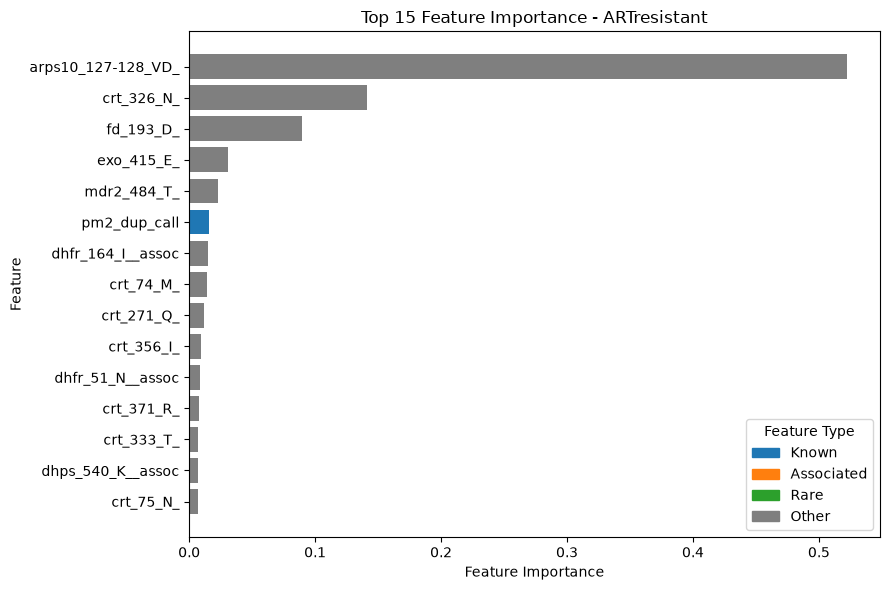

Saved: ../processed/feature_importance_plots/ARTresistant_feature_importance.png


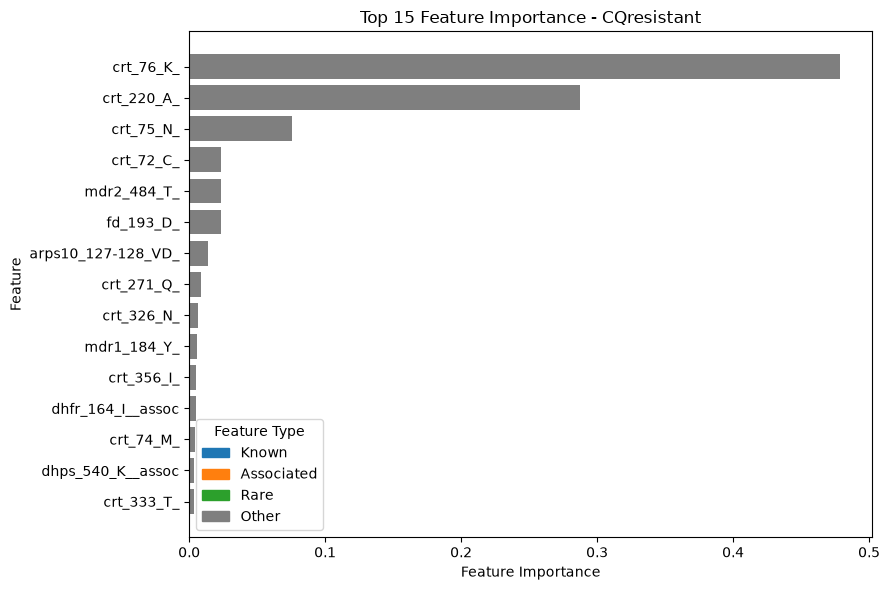

Saved: ../processed/feature_importance_plots/CQresistant_feature_importance.png


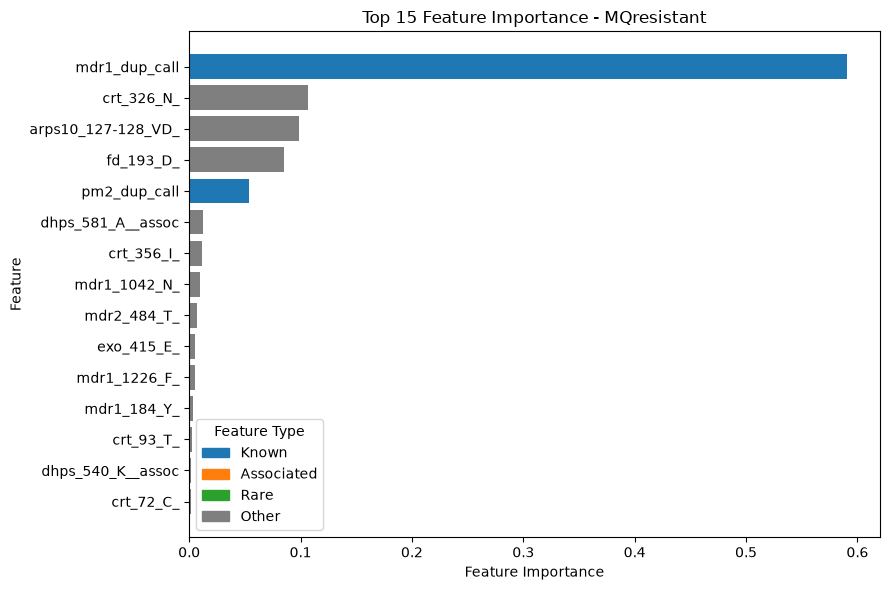

Saved: ../processed/feature_importance_plots/MQresistant_feature_importance.png


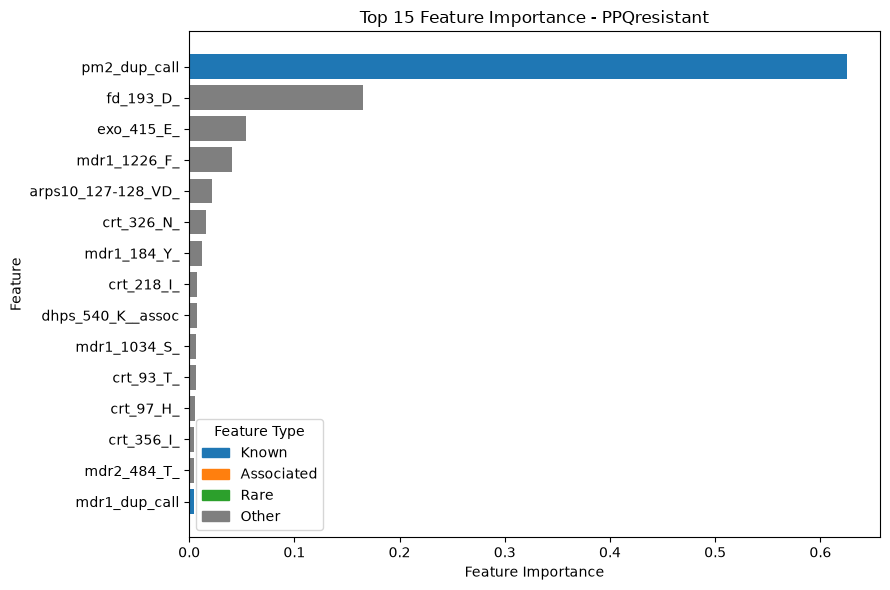

Saved: ../processed/feature_importance_plots/PPQresistant_feature_importance.png


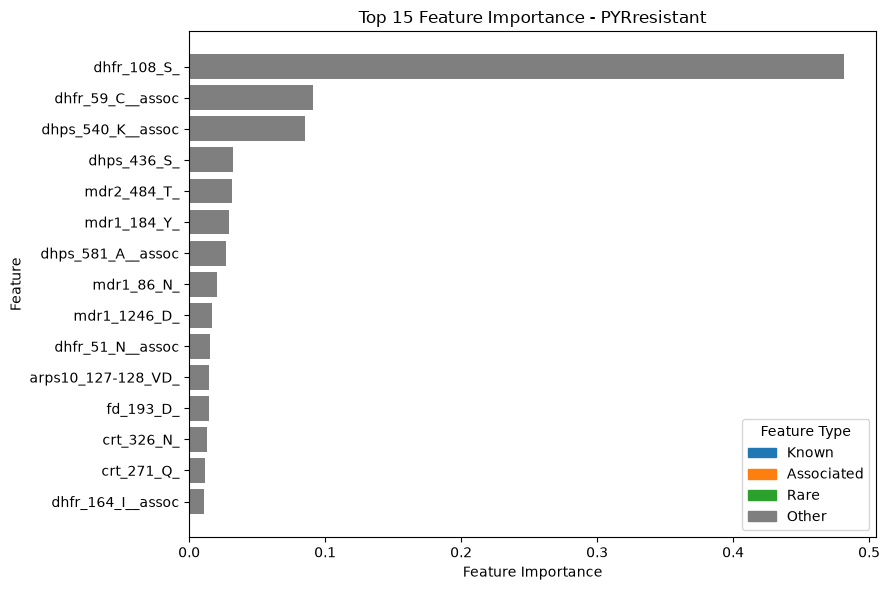

Saved: ../processed/feature_importance_plots/PYRresistant_feature_importance.png


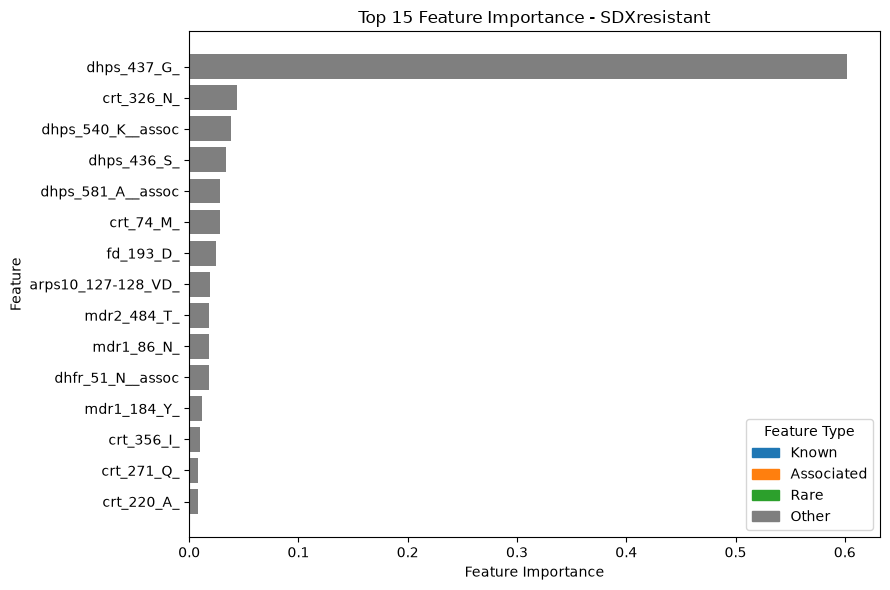

Saved: ../processed/feature_importance_plots/SDXresistant_feature_importance.png


In [ ]:

# Create folder for plots
os.makedirs("../processed/feature_importance_plots", exist_ok=True)


# --------------------------------------------------
# Define feature category
# --------------------------------------------------

def get_feature_category(feature):

    if feature in known_cols:
        return "Known"

    elif feature in associated_cols:
        return "Associated"

    elif feature in rare_cols:
        return "Rare"

    else:
        return "Other"


# --------------------------------------------------
# Color mapping
# --------------------------------------------------

color_map = {
    "Known": "tab:blue",
    "Associated": "tab:orange",
    "Rare": "tab:green",
    "Other": "tab:gray"
}


# --------------------------------------------------
# Plot and save for every drug
# --------------------------------------------------

for drug, importance in feature_importance.items():

    # Top 15 features
    top_features = importance.head(15).sort_values()

    # Get category for each feature
    categories = [
        get_feature_category(feature)
        for feature in top_features.index
    ]

    # Get color for each feature
    colors = [
        color_map[category]
        for category in categories
    ]

    # Create figure
    plt.figure(figsize=(9, 6))

    plt.barh(
        top_features.index,
        top_features.values,
        color=colors
    )

    plt.title(f"Top 15 Feature Importance - {drug}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    # Legend
    legend_elements = [
        Patch(color="tab:blue", label="Known"),
        Patch(color="tab:orange", label="Associated"),
        Patch(color="tab:green", label="Rare"),
        Patch(color="tab:gray", label="Other")
    ]

    plt.legend(
        handles=legend_elements,
        title="Feature Type"
    )

    plt.tight_layout()

    # --------------------------------------------------
    # SAVE PNG
    # --------------------------------------------------

    filename = f"../processed/feature_importance_plots/{drug}_feature_importance.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Close figure to prevent memory buildup
    plt.close()

    print(f"Saved: {filename}")

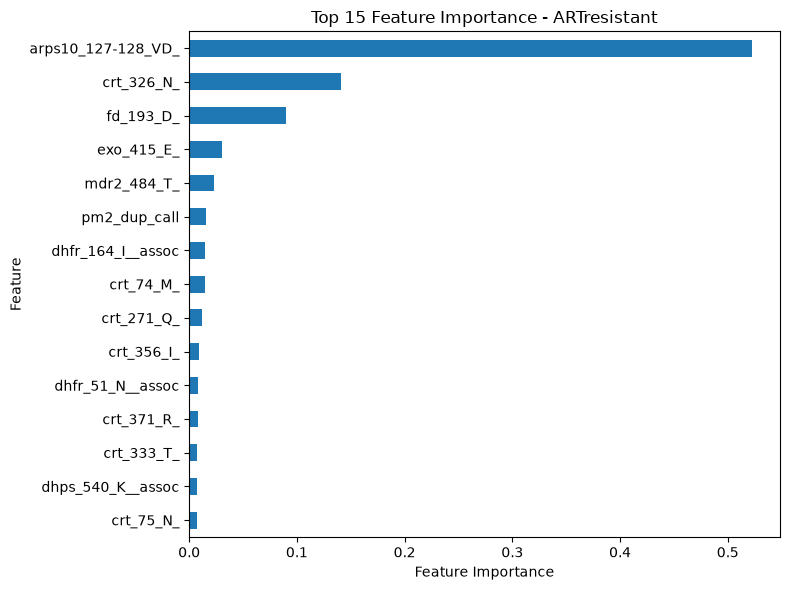

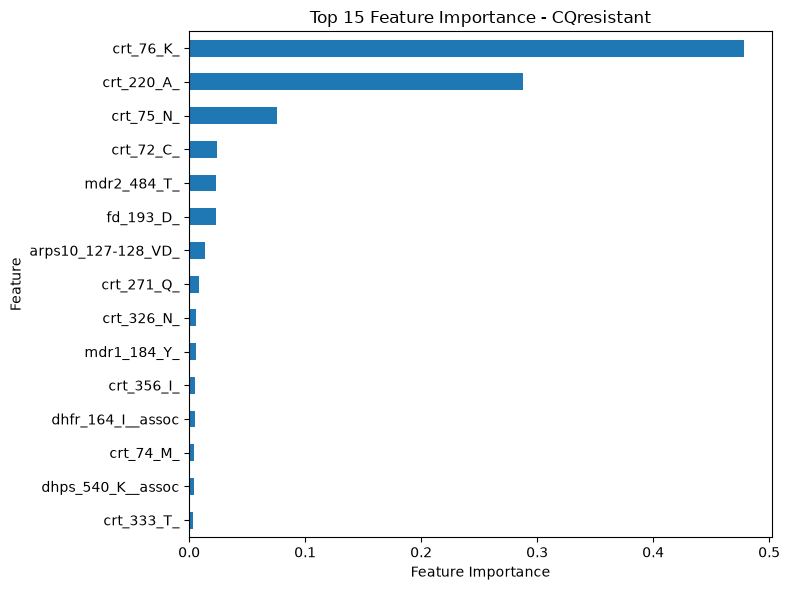

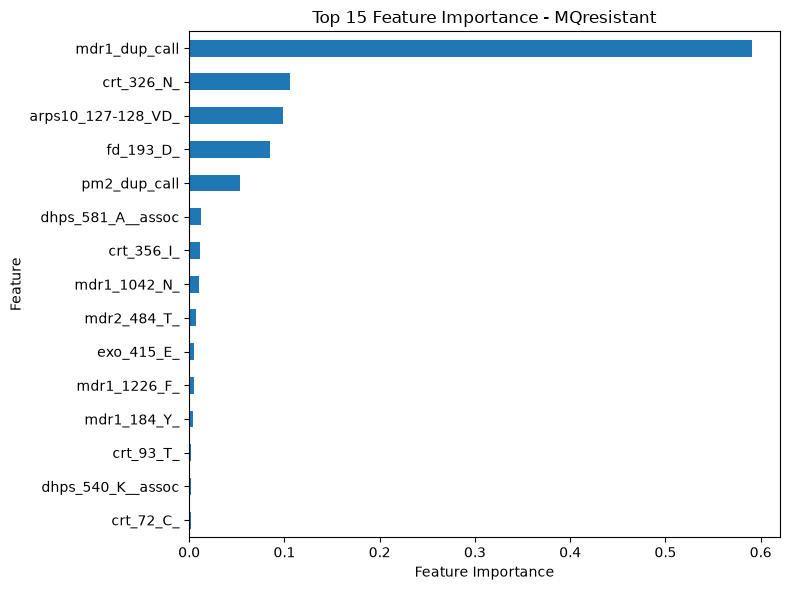

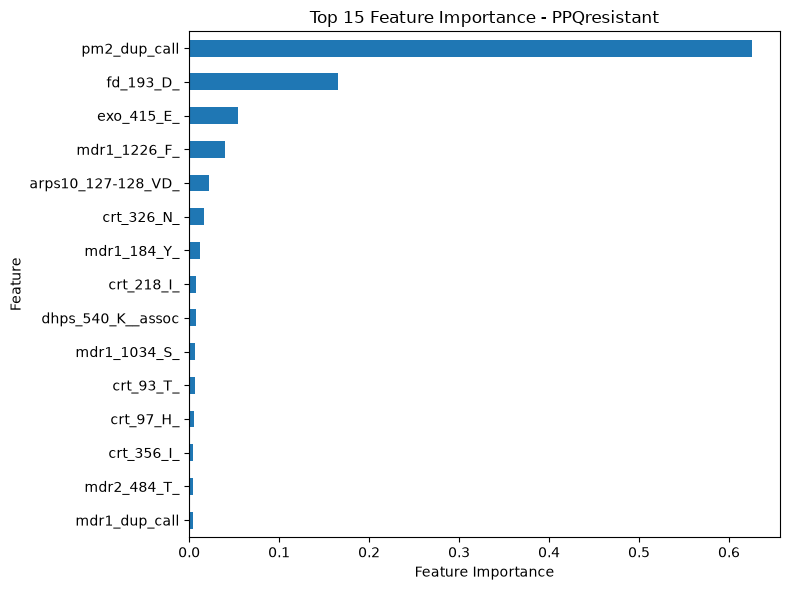

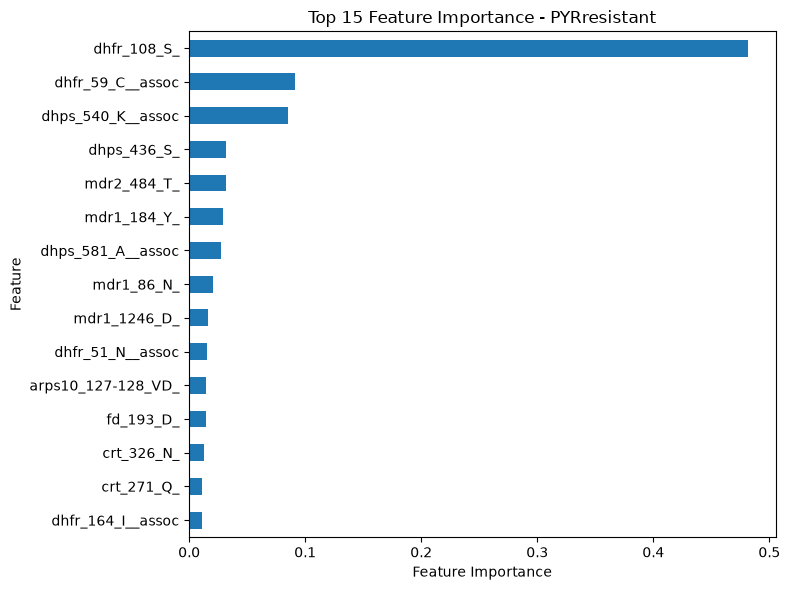

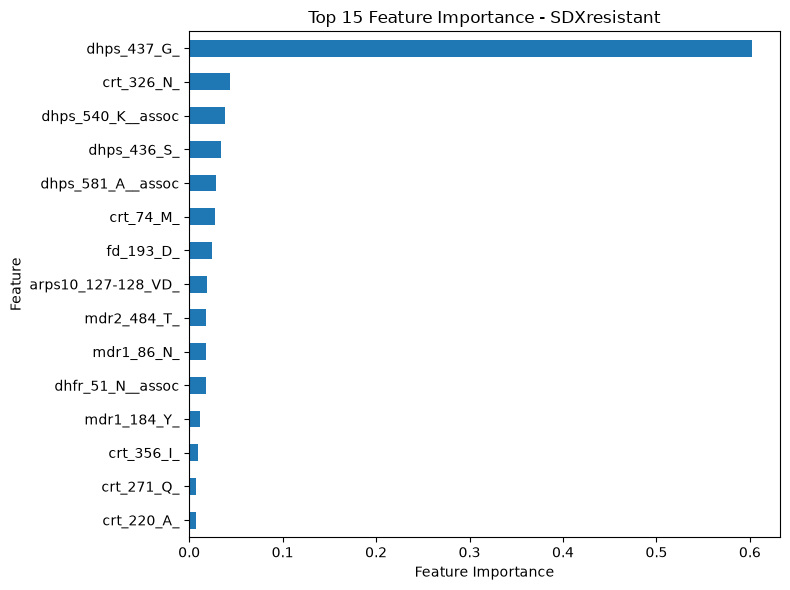

In [ ]:
import matplotlib.pyplot as plt

for drug, importance in feature_importance.items():

    # Get top 15 features
    top_features = importance.head(15)

    # Sort so the most important feature is at the top
    top_features = top_features.sort_values()

    # Create plot
    plt.figure(figsize=(8, 6))

    top_features.plot(
        kind="barh"
    )

    plt.title(f"Top 15 Feature Importance - {drug}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

#### MQ


In [ ]:
mq_model = xgb_models["MQresistant"]

In [ ]:
mq_prob = mq_model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.95, 0.05)

for threshold in thresholds:

    mq_pred = (mq_prob >= threshold).astype(int)

    f1 = f1_score(
        y_test_xgb["MQresistant"],
        mq_pred,
        zero_division=0
    )

    print(f"Threshold: {threshold:.2f} | F1: {f1:.3f}")

Threshold: 0.10 | F1: 0.973
Threshold: 0.15 | F1: 0.984
Threshold: 0.20 | F1: 0.984
Threshold: 0.25 | F1: 0.984
Threshold: 0.30 | F1: 0.984
Threshold: 0.35 | F1: 0.984
Threshold: 0.40 | F1: 0.988
Threshold: 0.45 | F1: 0.988
Threshold: 0.50 | F1: 0.980
Threshold: 0.55 | F1: 0.980
Threshold: 0.60 | F1: 0.980
Threshold: 0.65 | F1: 0.980
Threshold: 0.70 | F1: 0.980
Threshold: 0.75 | F1: 0.976
Threshold: 0.80 | F1: 0.968
Threshold: 0.85 | F1: 0.968
Threshold: 0.90 | F1: 0.964


In [ ]:
print(
    classification_report(
        y_test_xgb["MQresistant"],
        (mq_prob >= 0.5).astype(int),
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4756
           1       0.98      0.98      0.98       126

    accuracy                           1.00      4882
   macro avg       0.99      0.99      0.99      4882
weighted avg       1.00      1.00      1.00      4882



In [ ]:
from sklearn.metrics import average_precision_score

mq_pr_auc = average_precision_score(
    y_test_xgb["MQresistant"],
    mq_prob
)

print("MQ PR-AUC:", mq_pr_auc)

MQ PR-AUC: 0.9871213932894033


In [ ]:
from sklearn.metrics import average_precision_score, f1_score

mq_train_prob = xgb_models["MQresistant"].predict_proba(
    X_train_xgb
)[:, 1]

mq_test_prob = xgb_models["MQresistant"].predict_proba(
    X_test_xgb
)[:, 1]

print("Train PR-AUC:",
      average_precision_score(y_train_xgb["MQresistant"], mq_train_prob))

print("Test PR-AUC:",
      average_precision_score(y_test_xgb["MQresistant"], mq_test_prob))

Train PR-AUC: 0.9859925175954884
Test PR-AUC: 0.9871213932894033


## Haplotypes associated with drug resistance

In [ ]:
# columns for mutations in Sulfadoxine-Pyrimethamine (treatment) and Sulfadoxine-Pyrimethamine (IPTp)
dhfr_cols = [
    "dhfr_51[N]",
    "dhfr_59[C]",
    "dhfr_108[S]",
    "dhfr_164[I]"
]

dhps_cols = [
    "dhps_437[G]",
    "dhps_540[K]",
    "dhps_581[A]",
    "dhps_613[A]"
]

combo_cols = dhfr_cols + dhps_cols

In [ ]:
# dealing with SP-IPTp (sextuple mutant)
def classify_sp(row):

    cols = [
        "dhfr_51[N]",
        "dhfr_59[C]",
        "dhfr_108[S]",
        "dhfr_164[I]",
        "dhps_437[G]",
        "dhps_540[K]",
        "dhps_581[A]",
        "dhps_613[A]"
    ]

    if any(is_ambiguous(row[c]) for c in cols):
        return "Rare"

    if (
        row["dhfr_51[N]"] == "I"
        and row["dhfr_59[C]"] == "R"
        and row["dhfr_108[S]"] == "N"
        and row["dhps_437[G]"] == "G"
        and row["dhps_540[K]"] == "E"
        and (
            row["dhfr_164[I]"] == "L"
            or row["dhps_581[A]"] == "G"
            or row["dhps_613[A]"] in {"S", "T"}
        )
    ):
        return "Resistant"

    return "Sensitive"

In [ ]:
# helper function
def is_ambiguous(value):

    if pd.isna(value):
        return True

    value = str(value).strip()

    if value in {"-", "*", "!"}:
        return True

    return value.islower()

In [ ]:
# dealing with Pyrimethamine (triple mutant)
def classify_pyr(row):

    cols = [
        "dhfr_51[N]",
        "dhfr_59[C]",
        "dhfr_108[S]"
    ]

    if any(is_ambiguous(row[c]) for c in cols):
        return "Rare"

    if (
        row["dhfr_51[N]"] == "I"
        and row["dhfr_59[C]"] == "R"
        and row["dhfr_108[S]"] == "N"
    ):
        return "Resistant"

    return "Sensitive"

In [ ]:
# pyresistant is for triplet Pyrimethamine
encoded["PYRresistant"] = genotype.apply(classify_pyr, axis=1)
# Spresistant if for sextuple mutant
encoded["SPresistant"] = genotype.apply(classify_sp, axis=1)

In [ ]:
encoded.head()

,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,...,mdr1_184[Y],mdr1_1034[S],mdr1_1042[N],mdr1_1226[F],mdr1_1246[D],arps10_127-128[VD],fd_193[D],mdr2_484[T],PYRresistant,SPresistant
0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,Sensitive,Sensitive
1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,sensitive,sensitive,sensitive,Rare,sensitive,sensitive,sensitive,Resistant,Sensitive
2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,Resistant,Sensitive
3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Rare,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,Resistant,Sensitive
4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,sensitive,Resistant,Sensitive


In [ ]:
def encode(value, column):

    # Missing
    if pd.isna(value) or str(value).strip() == "":
        return "Missing"

    value = str(value).strip()

    # ---------- Special: copy number ----------
    # ----- Special: copy number ----------
    if column in ["mdr1_dup_call", "pm2_dup_call"]:
        if int(value) == 0:
            return "Sensitive"
        elif int(value) == 1:
            return "Resistant"
        elif int(value) in {"-", "*", "!"}:
            return "missing"
        else:
            return "rare"
    

    # ---------- Special: crt haplotype ----------
    if column == "crt_72-76[CVMNK]":

        haps = [x.strip() for x in value.split(",")]

        if any(h in {"CVIET", "SVMNT"} for h in haps):
            return "Resistant"

        if all(h == "CVMNK" for h in haps):
            return "Sensitive"

        return "Rare"

    # ---------- Special: kelch13 ----------
    if column == "kelch13_349-726_ns_changes":

        # Missing or unresolved
        if pd.isna(value):
            return "missing"

        value = str(value).strip()

        if value in {"-", "*", "!"}:
            return "missing"

        # Two haplotypes
        if "," in value:
            haps = [x.strip() for x in value.split(",")]

            # Same mutation on both haplotypes
            if len(set(haps)) == 1:
                value = haps[0]
            else:
                return "Rare"

        # Lowercase = heterozygous
        if value.islower():
            return "Rare"

        value = value.upper()

        # Wild type (if present in your data)
        if value in {"WT", "578S"}:
            return "Sensitive"

        # WHO resistance mutation
        if value in WHO_K13:
            return "Resistant"

        # Any other homozygous mutation
        return "Sensitive"
    
    

    # ---------- Multiple alleles ----------
    alleles = [a.strip() for a in value.split(",")]
    if len(alleles) > 1:

        if column in SPECIAL:
            if any(a in SPECIAL[column] for a in alleles):
                return "Resistant"
            return "Rare"

        # General columns
        if ref_aa[column] in alleles:
            return "Sensitive"

        return "Rare"

    # ---------- Single allele ----------

    allele = alleles[0]

    if column in SPECIAL:
        if allele in SPECIAL[column]:
            return "rare"

    if allele == ref_aa[column]:
        return "Sensitive"

    return "missing"

### Handling artesunate_mefloquine

In [ ]:
def classify_artesunate_mefloquine(row):

    art = row["kelch13_349-726_ns_changes"]
    mq = row["mdr1_dup_call"]

    # Missing
    if art == "Missing" or mq == "Missing":
        return "Missing"

    # Both resistant
    if art == "Resistant" and mq == "Resistant":
        return "Resistant"

    # At least one sensitive
    if art == "Sensitive" or mq == "Sensitive":
        return "Sensitive"

    # Rare/unknown combinations
    return "Rare"

In [ ]:
encoded["ASMQresistant"] = encoded.apply(
    classify_artesunate_mefloquine,
    axis=1
)

KeyError: 'kelch13_349-726_ns_changes'

### Handling piperaquine

In [ ]:
encoded.columns

Index(['Sample', 'crt_72[C]', 'crt_74[M]', 'crt_75[N]', 'crt_76[K]',
       'crt_72-76[CVMNK]', 'crt_93[T]', 'crt_97[H]', 'crt_218[I]',
       'crt_220[A]', 'crt_271[Q]', 'crt_326[N]', 'crt_333[T]', 'crt_353[G]',
       'crt_356[I]', 'crt_371[R]', 'dhfr_16[N]', 'dhfr_51[N]', 'dhfr_59[C]',
       'dhfr_108[S]', 'dhfr_164[I]', 'dhfr_306[S]', 'dhps_436[S]',
       'dhps_437[G]', 'dhps_540[K]', 'dhps_581[A]', 'dhps_613[A]',
       'exo_415[E]', 'mdr1_86[N]', 'mdr1_184[Y]', 'mdr1_1034[S]',
       'mdr1_1042[N]', 'mdr1_1226[F]', 'mdr1_1246[D]', 'arps10_127-128[VD]',
       'fd_193[D]', 'mdr2_484[T]', 'kelch13_349-726_ns_changes',
       'mdr1_dup_call', 'pm2_dup_call', 'PYRresistant', 'SPresistant',
       'ASMQresistant'],
      dtype='str')

In [ ]:
def classify_artesunate_mefloquine(row):

    art = row["kelch13_349-726_ns_changes"]
    mq = row["mdr1_dup_call"]

    # Missing
    if art == "Missing" or mq == "Missing":
        return "Missing"

    # Both resistant
    if art == "Resistant" and mq == "Resistant":
        return "Resistant"

    # At least one sensitive
    if art == "Sensitive" or mq == "Sensitive":
        return "Sensitive"

    # Rare/unknown combinations
    return "Rare"

In [ ]:
encoded

,Sample,crt_72[C],crt_74[M],crt_75[N],crt_76[K],crt_72-76[CVMNK],crt_93[T],crt_97[H],crt_218[I],crt_220[A],...,mdr1_1246[D],arps10_127-128[VD],fd_193[D],mdr2_484[T],kelch13_349-726_ns_changes,mdr1_dup_call,pm2_dup_call,PYRresistant,SPresistant,ASMQresistant
0,FP0008-C,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,Sensitive,Sensitive,Missing
1,FP0009-C,Sensitive,missing,missing,missing,Resistant,Sensitive,Sensitive,Sensitive,missing,...,missing,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,Resistant,Sensitive,Missing
2,FP0010-CW,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,Resistant,Sensitive,Missing
3,FP0011-CW,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,Resistant,Sensitive,Missing
4,FP0012-CW,Sensitive,missing,missing,missing,Resistant,Sensitive,Sensitive,Sensitive,missing,...,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,Resistant,Sensitive,Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24404,SPT92049,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,missing,Sensitive,Sensitive,Sensitive,missing,rare,rare,Resistant,Rare,Rare
24405,SPT92054,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,rare,Resistant,Sensitive,Missing
24406,SPT92057,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,...,Sensitive,Sensitive,Sensitive,Sensitive,missing,rare,rare,Resistant,Sensitive,Rare
24407,SPT94772,Sensitive,missing,missing,missing,Resistant,Sensitive,Sensitive,Sensitive,missing,...,missing,Sensitive,Sensitive,missing,missing,rare,rare,Resistant,Sensitive,Rare


## Filtering African countries only

,sample_id,year,qc_pass,study_id,region,country,country_id,site,site_id,ARTresistant,CQresistant,MQresistant,PPQresistant,PYRresistant,SDXresistant
0,FP0008-C,2014,True,1147,NaN,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,sensitive,sensitive,undetermined,undetermined
1,FP0009-C,2014,True,1147,NaN,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,sensitive,sensitive,resistant,sensitive
2,FP0010-CW,2014,True,1147,NaN,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,resistant
3,FP0011-CW,2014,True,1147,NaN,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,undetermined
4,FP0012-CW,2014,True,1147,NaN,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,undetermined,undetermined,resistant,sensitive


In [ ]:
metadata['ARTresistant'].unique()

<StringArray>
['sensitive', nan, 'undetermined', 'resistant']
Length: 4, dtype: str

In [ ]:
metadata['ARTresistant'].value_counts()

ARTresistant
sensitive       17147
resistant        3905
undetermined     3357
Name: count, dtype: int64

In [ ]:
metadata['ARTresistant'].isna().sum()

np.int64(8586)

In [ ]:
metadata['country'].unique()

<StringArray>
[                      'Mauritania',                           'Gambia',
                           'Guinea',                            'Kenya',
                         'Thailand',                         'Tanzania',
                            'Ghana',                         'Cambodia',
                        'Indonesia',                     'Burkina Faso',
                             'Mali',                 'Papua New Guinea',
                             'Peru',                       'Bangladesh',
                           'Malawi',                          'Vietnam',
                         'Colombia',                        'Venezuela',
                           'Uganda',                          'Myanmar',
                             'Laos', 'Democratic Republic of the Congo',
                          'Nigeria',                       'Madagascar',
                         'Cameroon',                    'Côte d'Ivoire',
                         'Ethiopia', 

<class 'pandas.DataFrame'>
Index: 20951 entries, 0 to 32994
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sample_id     20951 non-null  str    
 1   year          20951 non-null  int64  
 2   qc_pass       20951 non-null  bool   
 3   study_id      20951 non-null  int64  
 4   region        0 non-null      float64
 5   country       20951 non-null  str    
 6   country_id    20951 non-null  str    
 7   site          20951 non-null  str    
 8   site_id       20951 non-null  str    
 9   ARTresistant  14508 non-null  str    
 10  CQresistant   14508 non-null  str    
 11  MQresistant   14508 non-null  str    
 12  PPQresistant  14508 non-null  str    
 13  PYRresistant  14508 non-null  str    
 14  SDXresistant  14508 non-null  str    
dtypes: bool(1), float64(1), int64(2), str(11)
memory usage: 2.4 MB


In [ ]:
africa_df.columns

Index(['sample_id', 'year', 'qc_pass', 'study_id', 'country', 'country_id',
       'site', 'site_id', 'ARTresistant', 'CQresistant', 'MQresistant',
       'PPQresistant', 'PYRresistant', 'SDXresistant'],
      dtype='str')

In [ ]:
print(len(african_countries_geno))

20951


In [ ]:
african_countries_geno.head()

,Sample,crt_72[C],crt_74[M],crt_75[N],crt_76[K],crt_72-76[CVMNK],crt_93[T],crt_97[H],crt_218[I],crt_220[A],...,country,country_id,site,site_id,ARTresistant,CQresistant,MQresistant,PPQresistant,PYRresistant_y,SDXresistant
0,FP0008-C,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,sensitive,sensitive,undetermined,undetermined
1,FP0009-C,Sensitive,missing,missing,missing,Resistant,Sensitive,Sensitive,Sensitive,missing,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,sensitive,sensitive,resistant,sensitive
2,FP0010-CW,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,resistant
3,FP0011-CW,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,undetermined,undetermined,undetermined,resistant,undetermined
4,FP0012-CW,Sensitive,missing,missing,missing,Resistant,Sensitive,Sensitive,Sensitive,missing,...,Mauritania,MR,Hodh el Gharbi,Hodh el Gharbi,sensitive,resistant,undetermined,undetermined,resistant,sensitive


In [ ]:
african_countries_geno.info()

<class 'pandas.DataFrame'>
RangeIndex: 20951 entries, 0 to 20950
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Sample                      14508 non-null  str  
 1   crt_72[C]                   14508 non-null  str  
 2   crt_74[M]                   14508 non-null  str  
 3   crt_75[N]                   14508 non-null  str  
 4   crt_76[K]                   14508 non-null  str  
 5   crt_72-76[CVMNK]            14508 non-null  str  
 6   crt_93[T]                   14508 non-null  str  
 7   crt_97[H]                   14508 non-null  str  
 8   crt_218[I]                  14508 non-null  str  
 9   crt_220[A]                  14508 non-null  str  
 10  crt_271[Q]                  14508 non-null  str  
 11  crt_326[N]                  14508 non-null  str  
 12  crt_333[T]                  14508 non-null  str  
 13  crt_353[G]                  14508 non-null  str  
 14  crt_356[I]       

# Merging with East African Countries

In [ ]:
# loading east africa data 
east_genotype = pd.read_csv('../processed/east-country_year2010-2019.csv')

In [ ]:
east_genotype.columns

Index(['Unnamed: 0', 'sample_id', 'year', 'qc_pass', 'study_id', 'region',
       'country', 'country_id', 'site', 'site_id', 'ARTresistant',
       'CQresistant', 'MQresistant', 'PPQresistant', 'PYRresistant',
       'SDXresistant'],
      dtype='str')

In [ ]:
# saving East africa countries encoded genotype data
east_african_geno.to_csv('../processed/East_africa_geno.csv')

# Merging with West African Countries